## KIA 관중수 데이터 예측

In [54]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

In [ ]:
!pip install pytorch-tabnet

In [55]:
from pytorch_tabnet.tab_model import TabNetRegressor
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from chronos import Chronos2Pipeline
from korean_font import set_korean_font

# ===== 실행 환경 설정 =====
USE_GPU = False  # GPU 사용: True, CPU 사용: False

DEVICE = "cuda" if USE_GPU and torch.cuda.is_available() else "cpu"
DTYPE = "bfloat16" if DEVICE == "cuda" else "float32"
# ==========================

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12
set_korean_font()

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"사용 디바이스: {DEVICE} (dtype: {DTYPE})")

한글 폰트 설정: AppleGothic
PyTorch version: 2.10.0
CUDA available: False
사용 디바이스: cpu (dtype: float32)


In [56]:
df = pd.read_csv('data/baseball/KBO_2023_2025_FINAL_MASTER_2160.csv',encoding='utf-8-sig')

In [57]:
df.head()

,날짜,경기_시간,상태,홈,방문,홈_점수,방문_점수,승리팀,경기_순번,더블헤더냐,...,관중수,지점명,지점,평균기온(°C),일강수량(mm),평균 풍속(m/s),합계 일사량(MJ/m2),평균 전운량(1/10),연도,평균 상대습도(%)
0,2023-04-01,14:00,정상종료,KT,LG,11,6,KT,1,0,...,18700,수원,119.0,14.7,0.0,1.4,21.67,0.5,2023,47.9
1,2023-04-01,14:00,정상종료,SSG,KIA,4,1,SSG,1,0,...,23000,인천,112.0,15.0,0.0,1.9,21.56,1.3,2023,50.0
2,2023-04-01,14:00,정상종료,두산,롯데,12,10,두산,1,0,...,23750,서울,108.0,17.5,0.0,1.8,21.48,1.8,2023,40.4
3,2023-04-01,14:00,정상종료,삼성,NC,0,8,NC,1,0,...,24000,대구,143.0,15.0,0.0,3.3,22.11,0.9,2023,54.5
4,2023-04-01,14:00,정상종료,키움,한화,3,2,키움,1,0,...,16000,서울,108.0,17.5,0.0,1.8,21.48,1.8,2023,40.4


In [58]:
# 2. 누적 승률 및 순위 계산을 위한 데이터 준비
# 각 팀별로 매일의 승/패/무 기록을 길게 늘어뜨립니다.
matches = []
for _, row in df.iterrows():
    date = row['날짜']
    year = row['연도']
    
    # 홈팀 결과
    home_win = 1 if row['승리팀'] == row['홈'] else 0
    home_loss = 1 if row['승리팀'] == row['방문'] else 0
    home_tie = 1 if row['승리팀'] not in [row['홈'], row['방문']] else 0
    matches.append({'날짜': date, '연도': year, '팀명': row['홈'], '승': home_win, '패': home_loss, '무': home_tie})
    
    # 방문팀 결과
    away_win = 1 if row['승리팀'] == row['방문'] else 0
    away_loss = 1 if row['승리팀'] == row['홈'] else 0
    away_tie = 1 if row['승리팀'] not in [row['홈'], row['방문']] else 0
    matches.append({'날짜': date, '연도': year, '팀명': row['방문'], '승': away_win, '패': away_loss, '무': away_tie})

df_matches = pd.DataFrame(matches)

# 3. 팀별, 연도별 누적 승률 계산
# 날짜별로 정렬한 뒤 누적 합계를 구합니다.
df_matches = df_matches.sort_values(by=['연도', '팀명', '날짜'])
df_matches['누적승'] = df_matches.groupby(['연도', '팀명'])['승'].cumsum()
df_matches['누적패'] = df_matches.groupby(['연도', '팀명'])['패'].cumsum()
df_matches['누적무'] = df_matches.groupby(['연도', '팀명'])['무'].cumsum()

# 승률 = 승 / (승 + 패) (무승부는 계산 제외)
df_matches['승률'] = np.where(
    (df_matches['누적승'] + df_matches['누적패']) > 0,
    df_matches['누적승'] / (df_matches['누적승'] + df_matches['누적패']),
    0
)
# 일간순위 계산: 날짜별로 승률 기준 내림차순 순위
df_matches['일간순위'] = df_matches.groupby('날짜')['승률'].rank(method='min', ascending=False).astype(int)
# 날짜+팀명 기준 중복 제거 (마지막 기록 유지)
df_matches = df_matches.drop_duplicates(subset=['날짜', '팀명'], keep='last')

# 일간순위 계산
df_matches['일간순위'] = df_matches.groupby('날짜')['승률'].rank(method='dense', ascending=False).astype(int)

# 확인
print(f"일간순위 범위: {df_matches['일간순위'].min()} ~ {df_matches['일간순위'].max()}")
print(f"날짜별 팀 수: {df_matches.groupby('날짜')['팀명'].nunique().unique()}")

# daily_rank 변수 생성
daily_rank = df_matches


# 5. 원본 데이터에 '홈팀의 일간 순위' 합치기
df = pd.merge(df, daily_rank[['날짜', '팀명', '일간순위', '승률']], left_on=['날짜', '홈'], right_on=['날짜', '팀명'], how='left')
df = df.rename(columns={'일간순위': '홈팀_일간순위', '승률': '홈팀_승률'}).drop(columns=['팀명'])

# 6. 원본 데이터에 '방문팀의 일간 순위' 합치기
df = pd.merge(df, daily_rank[['날짜', '팀명', '일간순위', '승률']], left_on=['날짜', '방문'], right_on=['날짜', '팀명'], how='left')
df = df.rename(columns={'일간순위': '방문팀_일간순위', '승률': '방문팀_승률'}).drop(columns=['팀명'])

df.head()

일간순위 범위: 1 ~ 10
날짜별 팀 수: [10  8  4  6  2]


,날짜,경기_시간,상태,홈,방문,홈_점수,방문_점수,승리팀,경기_순번,더블헤더냐,...,일강수량(mm),평균 풍속(m/s),합계 일사량(MJ/m2),평균 전운량(1/10),연도,평균 상대습도(%),홈팀_일간순위,홈팀_승률,방문팀_일간순위,방문팀_승률
0,2023-04-01,14:00,정상종료,KT,LG,11,6,KT,1,0,...,0.0,1.4,21.67,0.5,2023,47.9,1,1.0,2,0.0
1,2023-04-01,14:00,정상종료,SSG,KIA,4,1,SSG,1,0,...,0.0,1.9,21.56,1.3,2023,50.0,1,1.0,2,0.0
2,2023-04-01,14:00,정상종료,두산,롯데,12,10,두산,1,0,...,0.0,1.8,21.48,1.8,2023,40.4,1,1.0,2,0.0
3,2023-04-01,14:00,정상종료,삼성,NC,0,8,NC,1,0,...,0.0,3.3,22.11,0.9,2023,54.5,2,0.0,1,1.0
4,2023-04-01,14:00,정상종료,키움,한화,3,2,키움,1,0,...,0.0,1.8,21.48,1.8,2023,40.4,1,1.0,2,0.0


In [59]:
# '홈' 컬럼이 'KIA'인 행만 남기기
df = df[df['홈'] == 'KIA'].copy()
df.reset_index(drop=True, inplace=True)

print(f"KIA 홈 경기 수: {len(df)}")
df.head()

KIA 홈 경기 수: 215


,날짜,경기_시간,상태,홈,방문,홈_점수,방문_점수,승리팀,경기_순번,더블헤더냐,...,일강수량(mm),평균 풍속(m/s),합계 일사량(MJ/m2),평균 전운량(1/10),연도,평균 상대습도(%),홈팀_일간순위,홈팀_승률,방문팀_일간순위,방문팀_승률
0,2023-04-07,18:30,정상종료,KIA,두산,1,4,두산,1,0,...,0.6,1.3,16.07,5.0,2023,77.3,5,0.333333,2,0.666667
1,2023-04-08,17:00,정상종료,KIA,두산,7,6,KIA,1,0,...,0.0,1.4,25.15,0.8,2023,47.6,5,0.500000,4,0.571429
2,2023-04-09,14:00,정상종료,KIA,두산,2,3,두산,1,0,...,0.0,1.0,26.89,0.3,2023,47.5,5,0.400000,3,0.625000
3,2023-04-11,18:30,정상종료,KIA,한화,4,5,한화,1,0,...,0.0,2.5,6.72,8.4,2023,77.4,5,0.333333,6,0.250000
4,2023-04-12,18:30,정상종료,KIA,한화,2,0,KIA,1,0,...,0.0,1.6,27.04,0.5,2023,19.4,3,0.428571,5,0.222222


In [60]:
# 구장이 '광주'인 경우만 남기기
df = df[df['구장'] == '광주'].copy()
df.reset_index(drop=True, inplace=True)

print(f"KIA 광주 홈 경기 수: {len(df)}")
df.head()

KIA 광주 홈 경기 수: 215


,날짜,경기_시간,상태,홈,방문,홈_점수,방문_점수,승리팀,경기_순번,더블헤더냐,...,일강수량(mm),평균 풍속(m/s),합계 일사량(MJ/m2),평균 전운량(1/10),연도,평균 상대습도(%),홈팀_일간순위,홈팀_승률,방문팀_일간순위,방문팀_승률
0,2023-04-07,18:30,정상종료,KIA,두산,1,4,두산,1,0,...,0.6,1.3,16.07,5.0,2023,77.3,5,0.333333,2,0.666667
1,2023-04-08,17:00,정상종료,KIA,두산,7,6,KIA,1,0,...,0.0,1.4,25.15,0.8,2023,47.6,5,0.500000,4,0.571429
2,2023-04-09,14:00,정상종료,KIA,두산,2,3,두산,1,0,...,0.0,1.0,26.89,0.3,2023,47.5,5,0.400000,3,0.625000
3,2023-04-11,18:30,정상종료,KIA,한화,4,5,한화,1,0,...,0.0,2.5,6.72,8.4,2023,77.4,5,0.333333,6,0.250000
4,2023-04-12,18:30,정상종료,KIA,한화,2,0,KIA,1,0,...,0.0,1.6,27.04,0.5,2023,19.4,3,0.428571,5,0.222222


In [61]:
# '일강수량(mm)' 컬럼의 NaN 값을 0.0으로 채우기
df['일강수량(mm)'] = df['일강수량(mm)'].fillna(0.0)

# 잘 바뀌었는지 확인 (NaN이 없어졌는지 보세요!)
print("일강수량 결측치 개수:", df['일강수량(mm)'].isnull().sum())
df.head()

일강수량 결측치 개수: 0


,날짜,경기_시간,상태,홈,방문,홈_점수,방문_점수,승리팀,경기_순번,더블헤더냐,...,일강수량(mm),평균 풍속(m/s),합계 일사량(MJ/m2),평균 전운량(1/10),연도,평균 상대습도(%),홈팀_일간순위,홈팀_승률,방문팀_일간순위,방문팀_승률
0,2023-04-07,18:30,정상종료,KIA,두산,1,4,두산,1,0,...,0.6,1.3,16.07,5.0,2023,77.3,5,0.333333,2,0.666667
1,2023-04-08,17:00,정상종료,KIA,두산,7,6,KIA,1,0,...,0.0,1.4,25.15,0.8,2023,47.6,5,0.500000,4,0.571429
2,2023-04-09,14:00,정상종료,KIA,두산,2,3,두산,1,0,...,0.0,1.0,26.89,0.3,2023,47.5,5,0.400000,3,0.625000
3,2023-04-11,18:30,정상종료,KIA,한화,4,5,한화,1,0,...,0.0,2.5,6.72,8.4,2023,77.4,5,0.333333,6,0.250000
4,2023-04-12,18:30,정상종료,KIA,한화,2,0,KIA,1,0,...,0.0,1.6,27.04,0.5,2023,19.4,3,0.428571,5,0.222222


In [62]:
# '날짜' 컬럼을 진짜 날짜 형식으로 변환
df['날짜'] = pd.to_datetime(df['날짜'])

In [63]:
# 1. 내 데이터에서 구장별/연도별 '최대 관중수' 찾기 (날짜에서 연도 즉석 추출)
capacity_df = df.groupby(['구장', df['날짜'].dt.year.rename('연도')])['관중수'].max().reset_index()
capacity_df.rename(columns={'관중수': '시즌최대관중'}, inplace=True)

# 2. 기존 데이터에 병합 (날짜의 연도 정보와 매칭)
df = pd.merge(df, capacity_df, left_on=['구장', df['날짜'].dt.year], right_on=['구장', '연도'], how='left')

# 3. '동원율(%)' 계산 및 불필요한 병합용 컬럼 삭제
df['동원율'] = round((df['관중수'] / df['시즌최대관중']) * 100, 1)
df.drop(columns=['연도', '시즌최대관중', 'key_1'], inplace=True, errors='ignore')

# 4. 확인
print(df[['날짜', '구장', '홈', '방문', '관중수', '동원율']].sort_values(by='동원율', ascending=False).head(5))

            날짜  구장    홈  방문    관중수    동원율
137 2024-09-12  광주  KIA  롯데  20500  100.0
142 2024-09-25  광주  KIA  롯데  20500  100.0
140 2024-09-23  광주  KIA  삼성  20500  100.0
139 2024-09-15  광주  KIA  키움  20500  100.0
138 2024-09-14  광주  KIA  키움  20500  100.0


## EDA

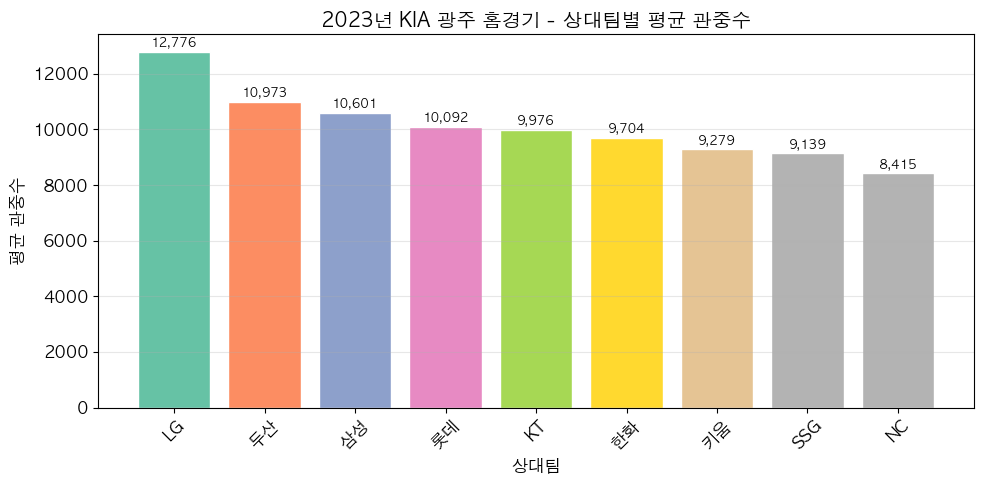

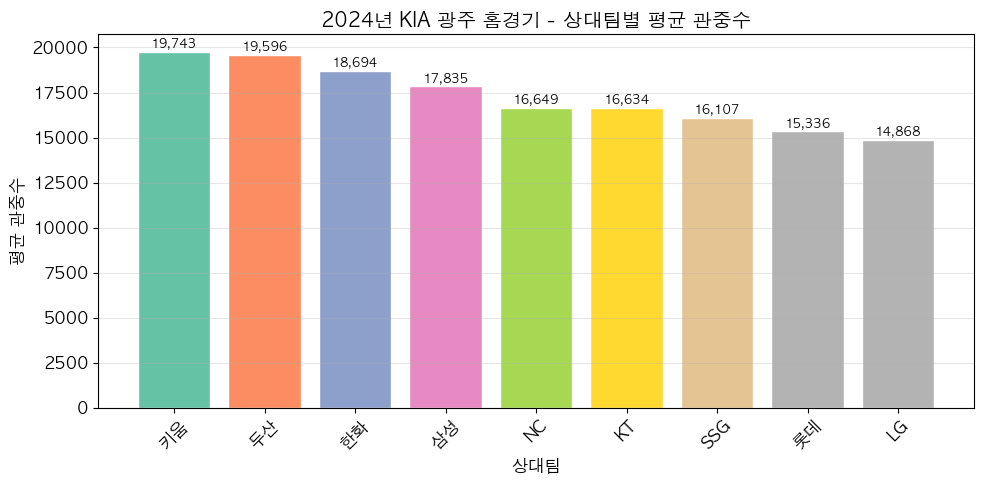

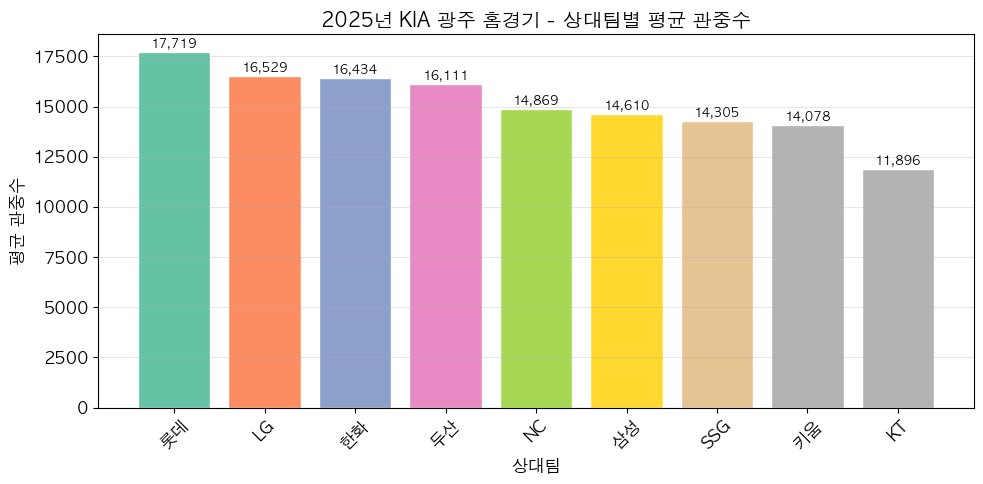

In [64]:
import matplotlib.pyplot as plt
import numpy as np

plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

if '연도' not in df.columns:
    df['연도'] = pd.to_datetime(df['날짜']).dt.year

years = sorted(df['연도'].unique())

for year in years:
    year_df = df[df['연도'] == year]
    team_avg = year_df.groupby('방문')['관중수'].mean().sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = plt.cm.Set2(np.linspace(0, 1, len(team_avg)))
    bars = ax.bar(team_avg.index, team_avg.values, color=colors, edgecolor='white')
    
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)
    
    ax.set_title(f'{year}년 KIA 광주 홈경기 - 상대팀별 평균 관중수', fontsize=14, fontweight='bold')
    ax.set_xlabel('상대팀')
    ax.set_ylabel('평균 관중수')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


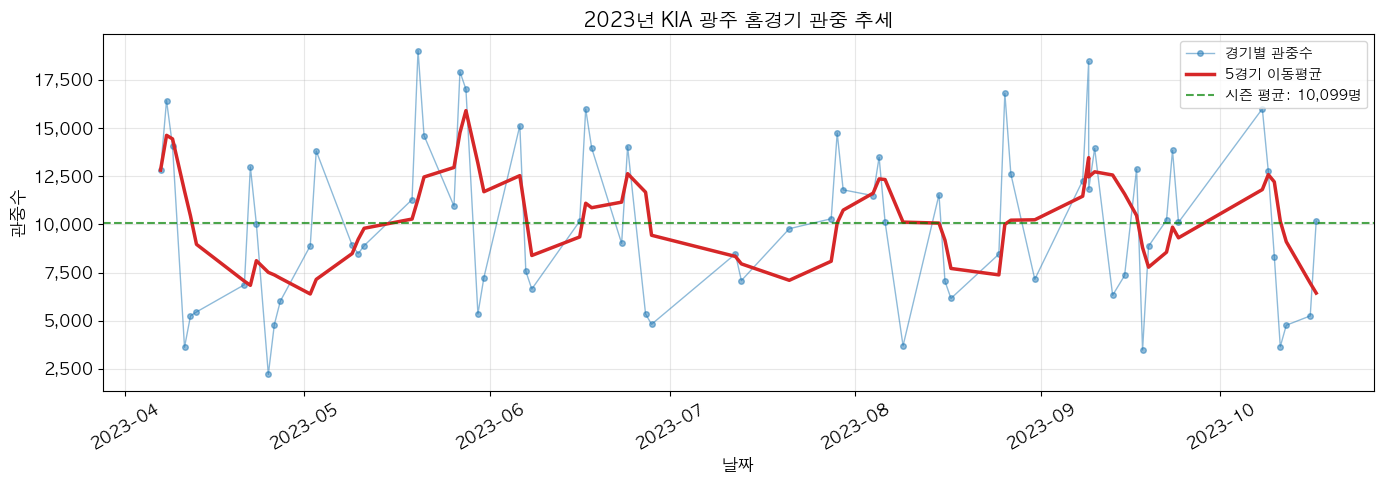

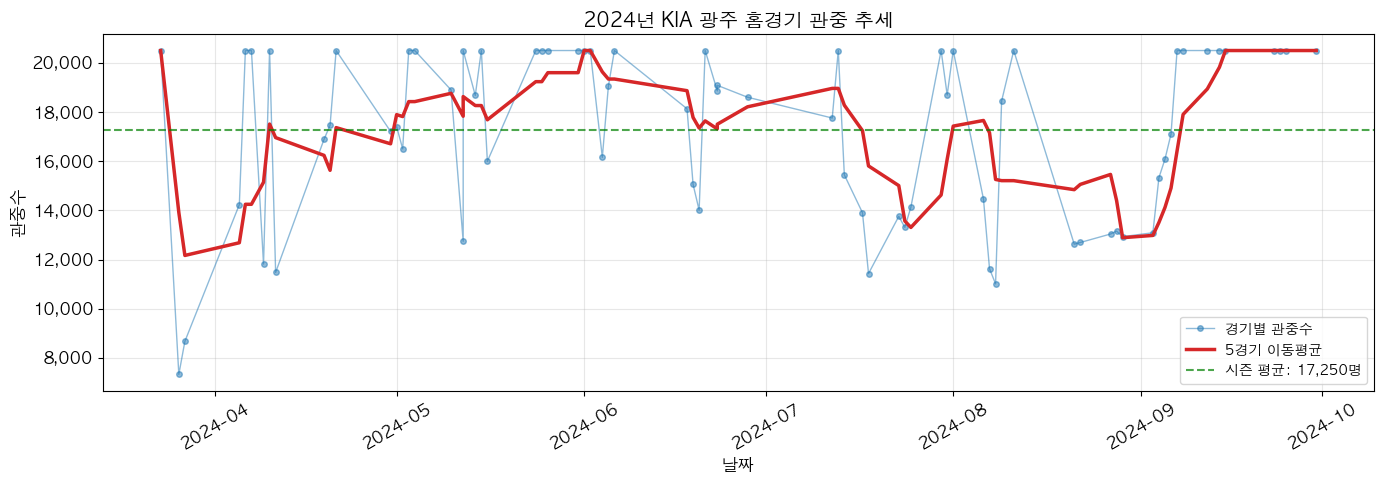

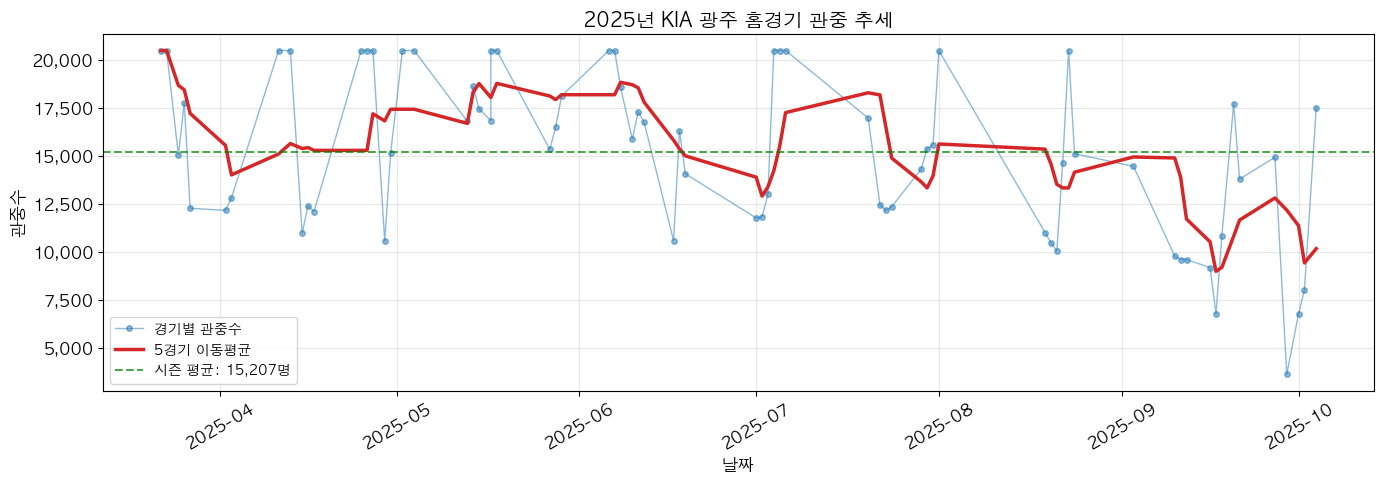

In [65]:
import matplotlib.pyplot as plt
import numpy as np

plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

if '연도' not in df.columns:
    df['연도'] = pd.to_datetime(df['날짜']).dt.year

df['날짜'] = pd.to_datetime(df['날짜'])
years = sorted(df['연도'].unique())

for year in years:
    year_df = df[df['연도'] == year].sort_values('날짜')
    
    fig, ax = plt.subplots(figsize=(14, 5))
    
    # 실제 관중수 (점 + 선)
    ax.plot(year_df['날짜'], year_df['관중수'], marker='o', markersize=4, 
            color='#1f77b4', alpha=0.5, linewidth=1, label='경기별 관중수')
    
    # 이동평균 추세선 (5경기)
    rolling_avg = year_df['관중수'].rolling(window=5, min_periods=1).mean()
    ax.plot(year_df['날짜'], rolling_avg, color='#d62728', linewidth=2.5, 
            label='5경기 이동평균')
    
    # 시즌 평균선
    season_avg = year_df['관중수'].mean()
    ax.axhline(y=season_avg, color='green', linestyle='--', linewidth=1.5, alpha=0.7,
               label=f'시즌 평균: {season_avg:,.0f}명')
    
    ax.set_title(f'{year}년 KIA 광주 홈경기 관중 추세', fontsize=14, fontweight='bold')
    ax.set_xlabel('날짜')
    ax.set_ylabel('관중수')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()


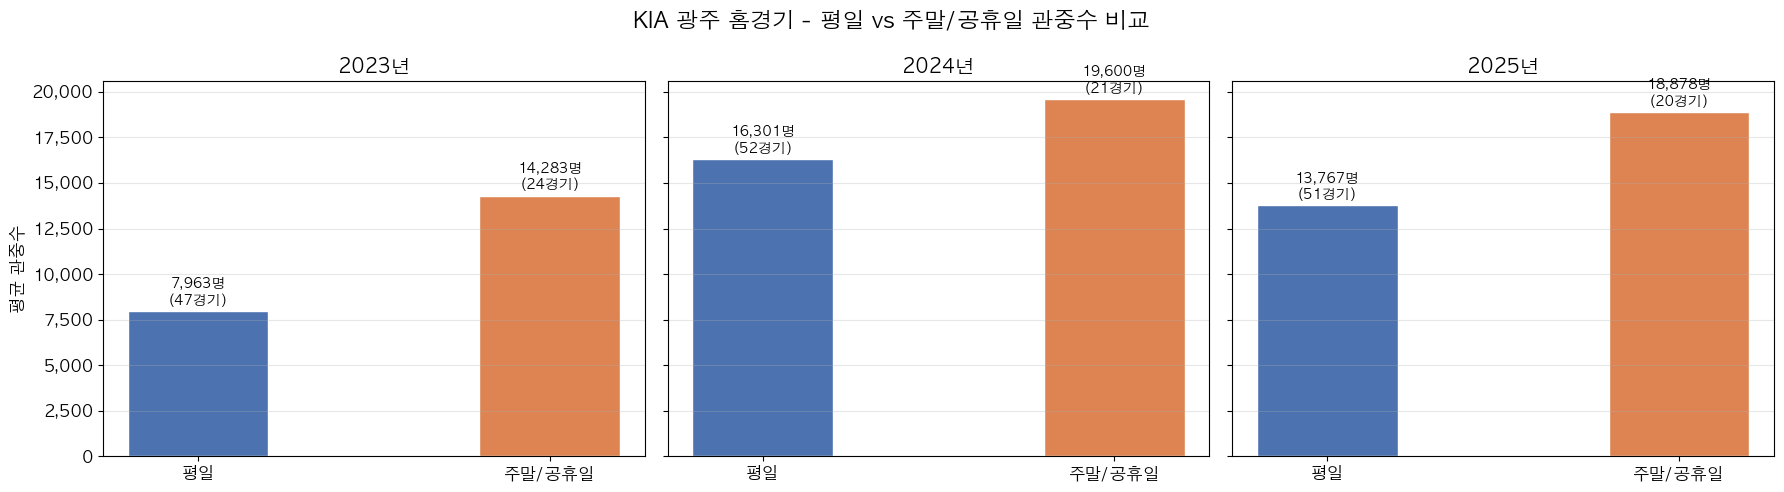

In [66]:
import holidays as hd

# 한국 공휴일 목록 생성 (데이터 연도 범위에 맞게 설정)
kr_holidays = hd.KR(years=[2023, 2024, 2025])
holidays = pd.Series(list(kr_holidays.keys()))

# 구분: 평일 vs 주말/공휴일
def classify_day(row):
    if row['날짜'] in holidays.values or row['요일'] in ['토', '일']:
        return '주말/공휴일'
    else:
        return '평일'

df['일구분'] = df.apply(classify_day, axis=1)

category_order = ['평일', '주말/공휴일']
colors = {'평일': '#4C72B0', '주말/공휴일': '#DD8452'}

fig, axes = plt.subplots(1, len(years), figsize=(6 * len(years), 5), sharey=True)
axes = np.atleast_1d(axes)

for ax, year in zip(axes, years):
    year_df = df[df['연도'] == year]
    stats = year_df.groupby('일구분')['관중수'].agg(['mean', 'count']).reindex(category_order).dropna()
    
    bars = ax.bar(stats.index, stats['mean'], color=[colors[c] for c in stats.index],
                  edgecolor='white', width=0.4)
    
    for bar, (cat, row) in zip(bars, stats.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{row["mean"]:,.0f}명\n({int(row["count"])}경기)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_title(f'{year}년', fontsize=14, fontweight='bold')
    if ax == axes[0]:
        ax.set_ylabel('평균 관중수')
    ax.grid(axis='y', alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('KIA 광주 홈경기 - 평일 vs 주말/공휴일 관중수 비교', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


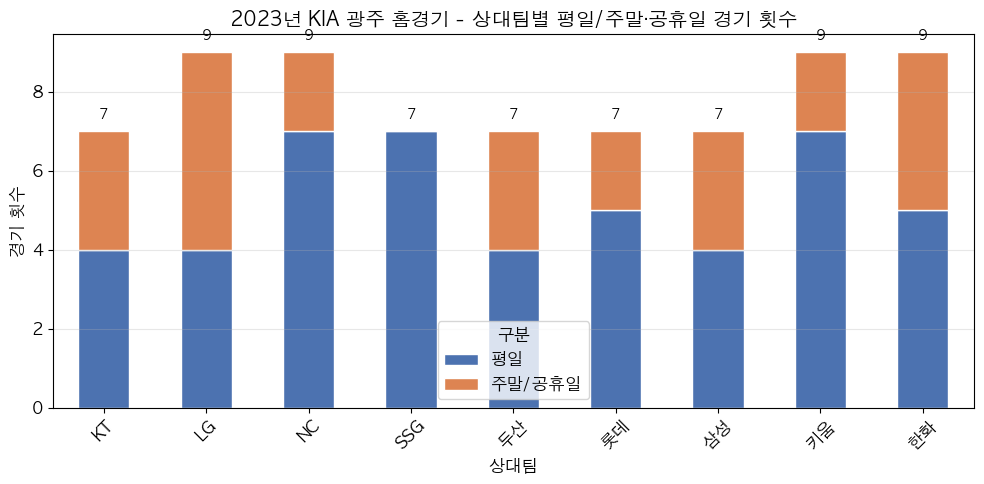

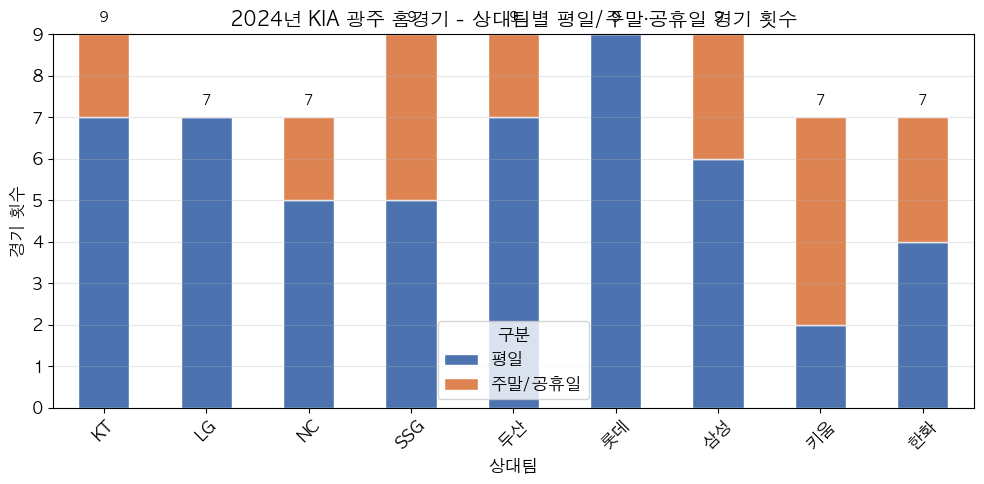

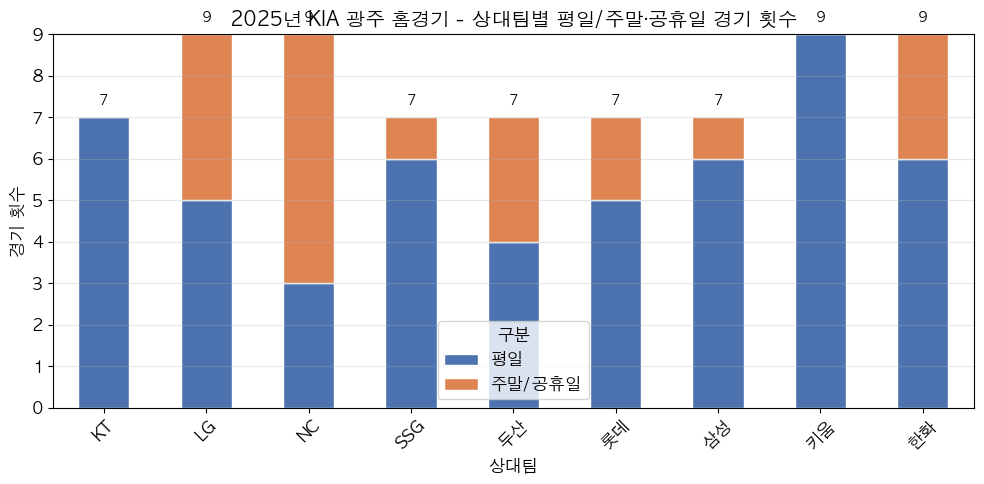

In [67]:
for year in years:
    year_df = df[df['연도'] == year]
    
    ct = pd.crosstab(year_df['방문'], year_df['일구분'])[['평일', '주말/공휴일']]
    ct = ct.sort_index()
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white')
    
    # 막대 위에 합계 표시
    for i, (team, row) in enumerate(ct.iterrows()):
        total = row.sum()
        ax.text(i, total + 0.3, f'{int(total)}', ha='center', fontsize=10, fontweight='bold')
    
    ax.set_title(f'{year}년 KIA 광주 홈경기 - 상대팀별 평일/주말·공휴일 경기 횟수', fontsize=14, fontweight='bold')
    ax.set_xlabel('상대팀')
    ax.set_ylabel('경기 횟수')
    ax.legend(title='구분')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


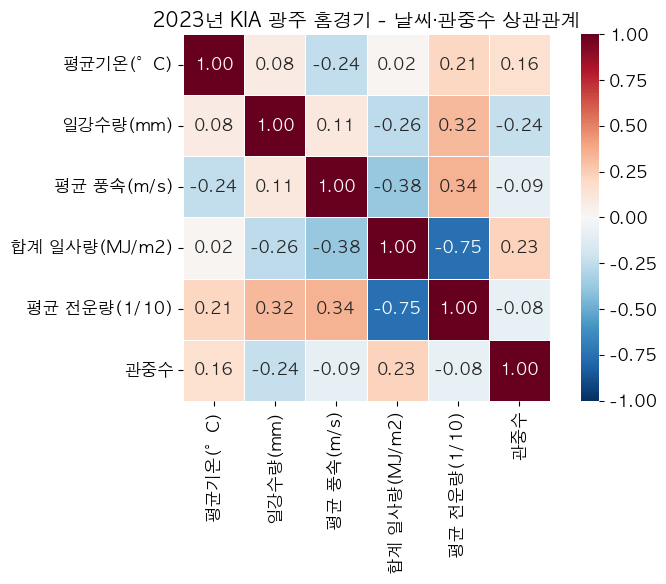

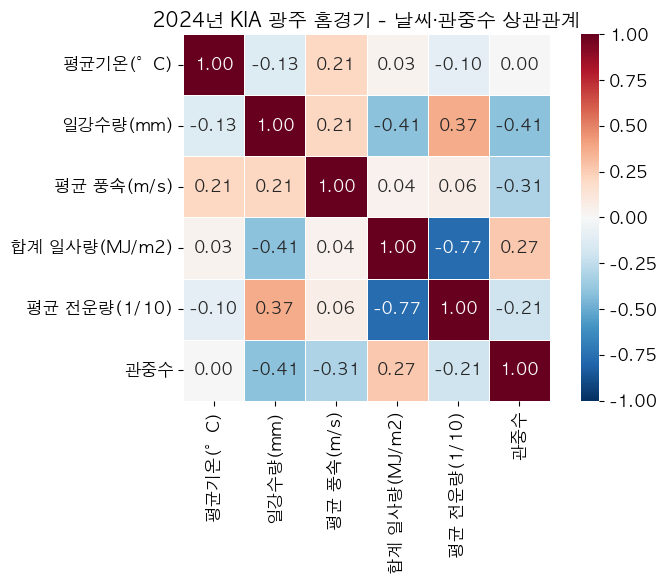

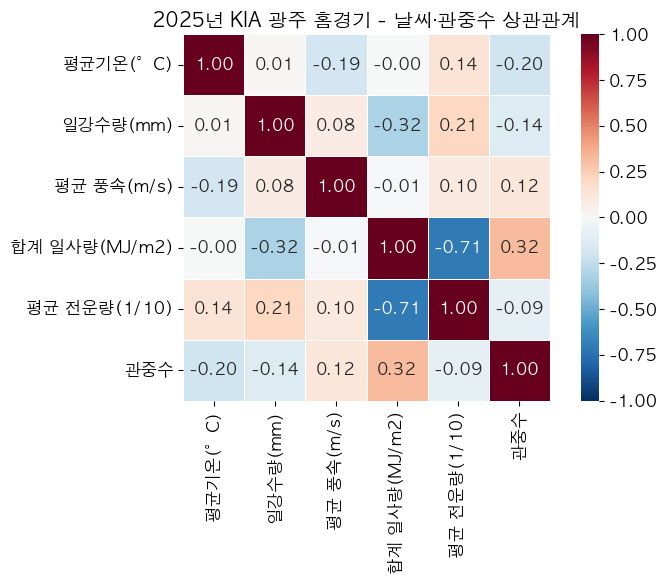

In [68]:
import seaborn as sns

weather_cols = ['평균기온(°C)', '일강수량(mm)', '평균 풍속(m/s)', '합계 일사량(MJ/m2)', '평균 전운량(1/10)']

for year in years:
    year_df = df[df['연도'] == year]
    
    corr = year_df[weather_cols + ['관중수']].corr()
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
    ax.set_title(f'{year}년 KIA 광주 홈경기 - 날씨·관중수 상관관계', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


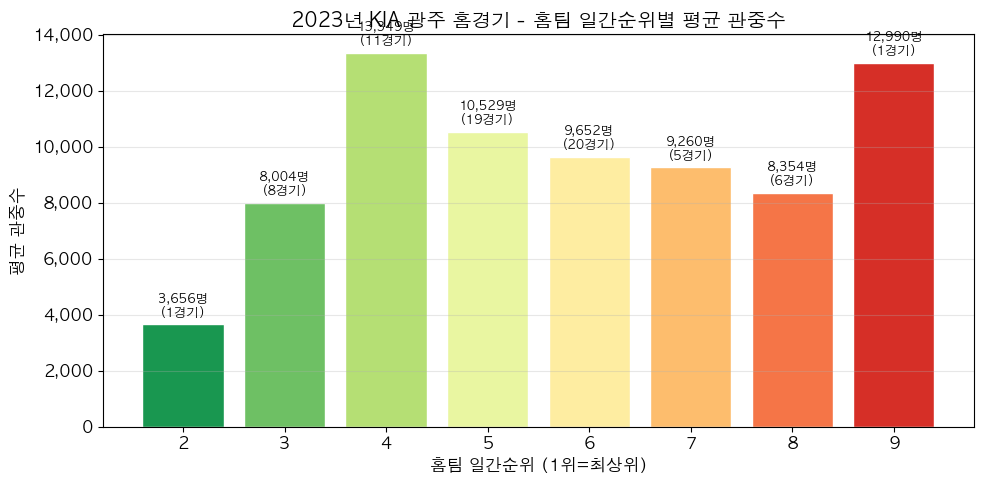

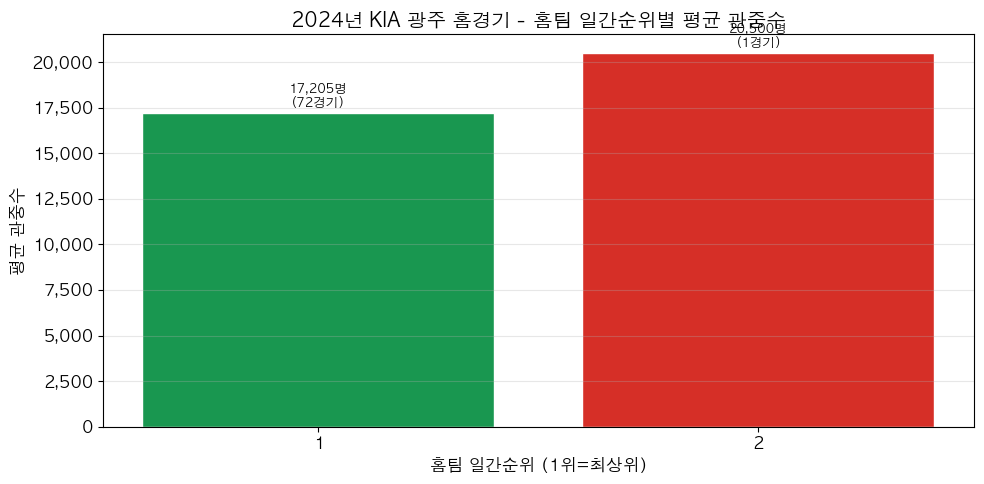

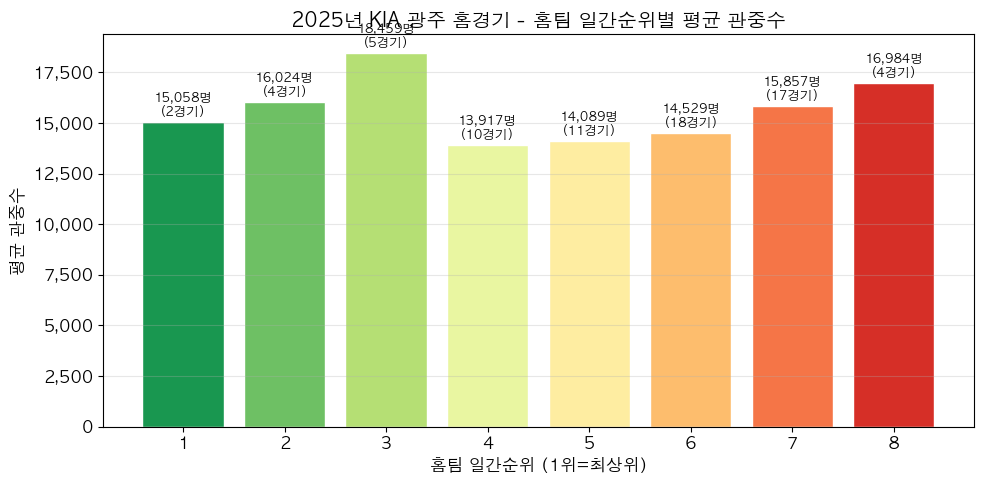

In [69]:
# 홈팀 일간순위가 있는지 확인
rank_col = '홈팀_일간순위' if '홈팀_일간순위' in df.columns else None

if rank_col is None:
    print("⚠️ '홈팀_일간순위' 컬럼이 없습니다. 먼저 일간순위 피처를 생성해주세요.")
else:
    for year in years:
        year_df = df[df['연도'] == year].dropna(subset=[rank_col])
        
        rank_avg = year_df.groupby(rank_col)['관중수'].agg(['mean', 'count']).sort_index()
        
        fig, ax = plt.subplots(figsize=(10, 5))
        bars = ax.bar(rank_avg.index.astype(int), rank_avg['mean'], 
                      color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(rank_avg))),
                      edgecolor='white')
        
        for bar, (rank, row) in zip(bars, rank_avg.iterrows()):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                    f'{row["mean"]:,.0f}명\n({int(row["count"])}경기)',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax.set_title(f'{year}년 KIA 광주 홈경기 - 홈팀 일간순위별 평균 관중수', fontsize=14, fontweight='bold')
        ax.set_xlabel('홈팀 일간순위 (1위=최상위)')
        ax.set_ylabel('평균 관중수')
        ax.set_xticks(rank_avg.index.astype(int))
        ax.grid(axis='y', alpha=0.3)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
        plt.tight_layout()
        plt.show()


🚀 KIA 타이거즈 연도별 일간순위 추세 그래프 그리기 시작!



/var/folders/3w/7bj38gqs0t58jb31pzzbbybr0000gn/T/ipykernel_11001/2169522248.py:64: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) AppleGothic.
  plt.tight_layout(pad=3.0)
/opt/anaconda3/envs/DL/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


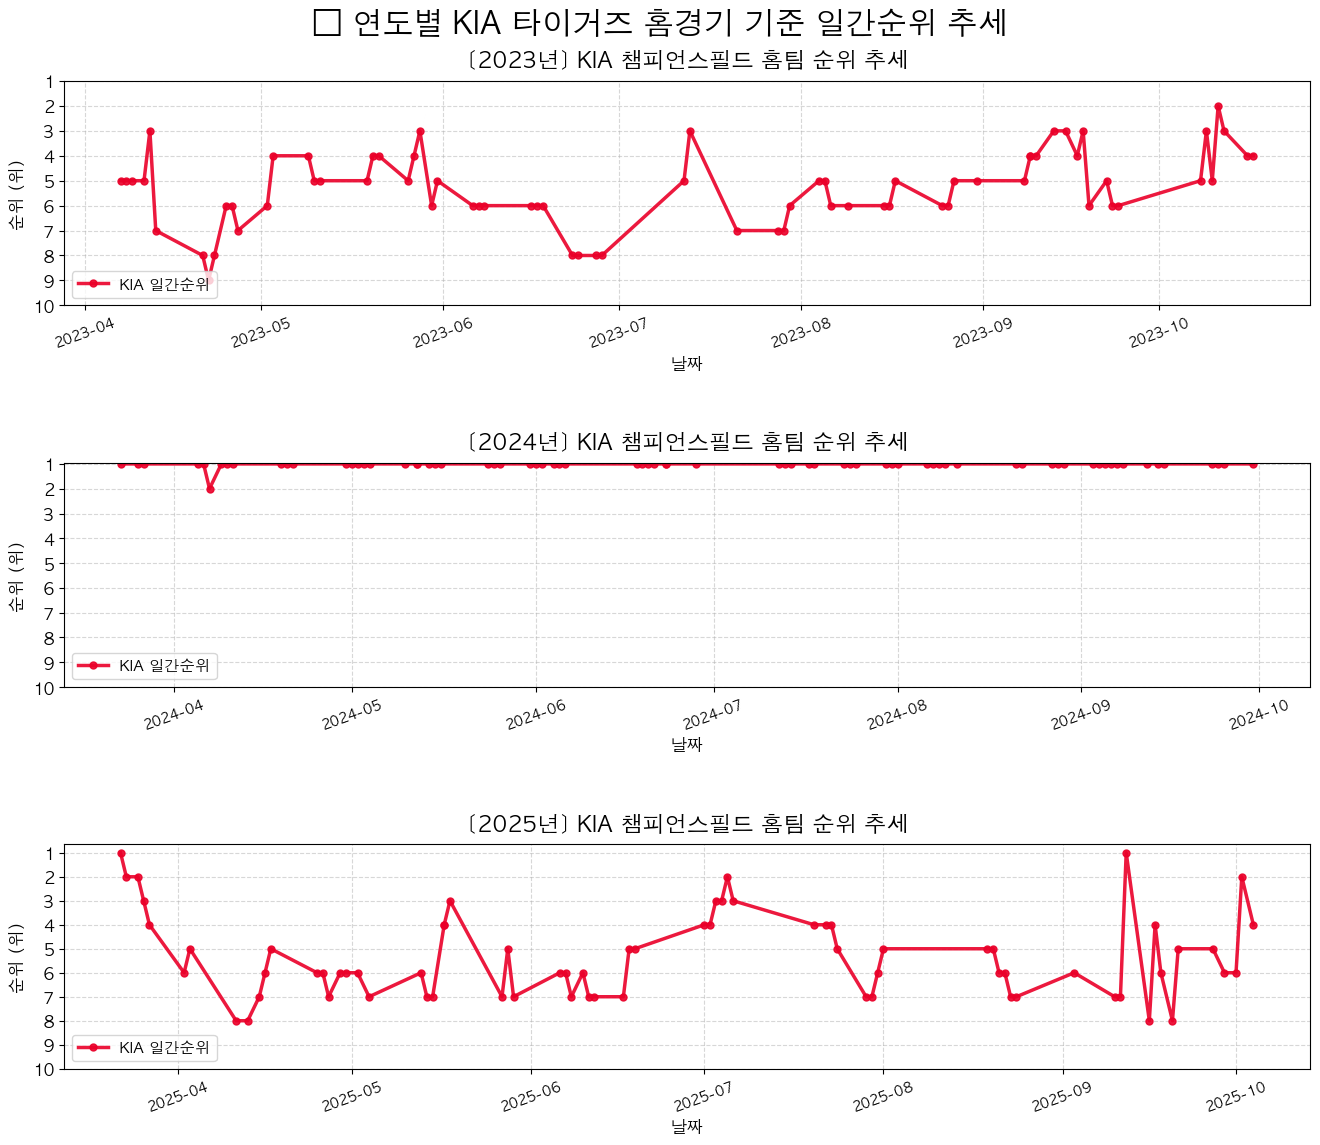

----------------------------------------------------------------------------------------------------
✅ KIA 순위 추세 그래프 완벽하게 출력 완료!


In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("🚀 KIA 타이거즈 연도별 일간순위 추세 그래프 그리기 시작!\n")

# 1. 데이터 복사 및 안전한 날짜 처리
df_rank = df.copy()

if '날짜' in df_rank.columns:
    df_rank['날짜'] = pd.to_datetime(df_rank['날짜'])
    df_rank = df_rank.sort_values('날짜')

# 2. 연도 파악
year_col = '연도' if '연도' in df_rank.columns else '년도'
years = sorted(df_rank[year_col].dropna().unique())

# 맥 폰트 설정
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False 

# ==============================================================================
# 3. 연도별(Yearly) 서브플롯 생성
# ==============================================================================
fig, axes = plt.subplots(nrows=len(years), ncols=1, figsize=(14, 4 * len(years)))
axes = np.atleast_1d(axes)

fig.suptitle('📈 연도별 KIA 타이거즈 홈경기 기준 일간순위 추세', fontsize=22, fontweight='bold', y=0.98)

for i, year in enumerate(years):
    ax = axes[i]
    
    # 해당 연도 데이터 추출
    year_df = df_rank[df_rank[year_col] == year].copy()
    
    # 혹시 모를 결측치 방지
    year_df = year_df.dropna(subset=['홈팀_일간순위'])
    
    if len(year_df) == 0:
        ax.set_title(f'[{year}년] 순위 데이터 없음', fontsize=15, color='gray')
        ax.axis('off')
        continue

    # 🌟 KIA 타이거즈 상징색(빨강)으로 순위 궤적 그리기!
    ax.plot(year_df['날짜'], year_df['홈팀_일간순위'], 
            color='#EA0029', marker='o', linestyle='-', linewidth=2.5, markersize=5, alpha=0.9,
            label='KIA 일간순위')
    
    # 🌟 핵심 포인트: 순위는 1위가 가장 높으므로 Y축을 뒤집어줍니다!
    ax.invert_yaxis()
    
    # Y축 눈금을 1위부터 10위까지 고정 (KBO는 10개 구단!)
    ax.set_yticks(range(1, 11))
    
    # 서브플롯 꾸미기
    ax.set_title(f'[{year}년] KIA 챔피언스필드 홈팀 순위 추세', fontsize=16, fontweight='bold', pad=10)
    ax.set_xlabel('날짜', fontsize=12)
    ax.set_ylabel('순위 (위)', fontsize=12) 
    
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=11, loc='lower left') # 1위가 위로 가므로 범례는 방해 안 되게 아래로!
    ax.tick_params(axis='x', rotation=20, labelsize=10)

plt.tight_layout(pad=3.0)
fig.subplots_adjust(top=0.92) 
plt.show()

print("-" * 100)
print("✅ KIA 순위 추세 그래프 완벽하게 출력 완료!")

In [71]:
# 광주 구장 최대 수용인원 기준 (약 21,500명)
FULL_CAPACITY = 20500
MAX_CAPACITY = FULL_CAPACITY

for year in years:
    year_df = df[df['연도'] == year].copy()
    
    # 만원 경기 (최대 수용인원의 95% 이상)
    full_games = year_df.nlargest(15, '관중수')
    # 관중수 최하위 15경기
    low_games = year_df.nsmallest(15, '관중수')
    
    print(f"\n{'='*80}")
    print(f"📊 {year}년 시즌 분석")
    print(f"{'='*80}")
    
    # --- 만원 경기 특징 ---
    print(f"\n🔴 만원 경기 ({len(full_games)}경기)")
    if len(full_games) > 0:
        print(f"  ▸ 요일 분포: {dict(full_games['요일'].value_counts())}")
        print(f"  ▸ 평일/주말: {dict(full_games['일구분'].value_counts())}")
        print(f"  ▸ 상대팀:    {dict(full_games['방문'].value_counts())}")
        print(f"  ▸ 평균기온:  {full_games['평균기온(°C)'].mean():.1f}°C")
        print(f"  ▸ 평균강수:  {full_games['일강수량(mm)'].mean():.1f}mm")
        if '홈팀_일간순위' in full_games.columns:
            print(f"  ▸ 홈팀 평균순위: {full_games['홈팀_일간순위'].mean():.1f}위")
        print(f"\n  [경기 목록]")
        display_cols = ['날짜', '방문', '요일', '일구분', '관중수', '평균기온(°C)', '일강수량(mm)']
        if '홈팀_일간순위' in full_games.columns:
            display_cols += ['홈팀_일간순위']
        display(full_games[display_cols].reset_index(drop=True))
    else:
        print("  → 만원 경기 없음")
    
    # --- 최하위 15경기 특징 ---
    print(f"\n🔵 관중수 최하위 15경기")
    print(f"  ▸ 요일 분포: {dict(low_games['요일'].value_counts())}")
    print(f"  ▸ 평일/주말: {dict(low_games['일구분'].value_counts())}")
    print(f"  ▸ 상대팀:    {dict(low_games['방문'].value_counts())}")
    print(f"  ▸ 평균기온:  {low_games['평균기온(°C)'].mean():.1f}°C")
    print(f"  ▸ 평균강수:  {low_games['일강수량(mm)'].mean():.1f}mm")
    if '홈팀_일간순위' in low_games.columns:
        print(f"  ▸ 홈팀 평균순위: {low_games['홈팀_일간순위'].mean():.1f}위")
    print(f"\n  [경기 목록]")
    display(low_games[display_cols].reset_index(drop=True))



📊 2023년 시즌 분석

🔴 만원 경기 (15경기)
  ▸ 요일 분포: {'토': np.int64(8), '일': np.int64(6), '화': np.int64(1)}
  ▸ 평일/주말: {'주말/공휴일': np.int64(14), '평일': np.int64(1)}
  ▸ 상대팀:    {'LG': np.int64(4), '키움': np.int64(2), '두산': np.int64(2), 'NC': np.int64(2), '한화': np.int64(1), '삼성': np.int64(1), 'SSG': np.int64(1), '롯데': np.int64(1), 'KT': np.int64(1)}
  ▸ 평균기온:  21.8°C
  ▸ 평균강수:  0.2mm
  ▸ 홈팀 평균순위: 5.1위

  [경기 목록]


,날짜,방문,요일,일구분,관중수,평균기온(°C),일강수량(mm),홈팀_일간순위
0,2023-05-20,키움,토,주말/공휴일,19030,20.6,0.0,4
1,2023-09-09,LG,토,주말/공휴일,18462,25.1,0.0,4
2,2023-05-27,LG,토,주말/공휴일,17931,22.7,0.0,4
3,2023-05-28,LG,일,주말/공휴일,17015,22.7,1.3,3
4,2023-08-26,한화,토,주말/공휴일,16812,26.0,0.0,6
5,2023-04-08,두산,토,주말/공휴일,16432,9.2,0.0,5
6,2023-10-08,삼성,일,주말/공휴일,16005,17.9,1.4,5
7,2023-06-17,NC,토,주말/공휴일,15992,24.8,0.0,6
8,2023-06-06,SSG,화,평일,15130,21.6,0.0,6
9,2023-07-29,롯데,토,주말/공휴일,14754,29.6,0.0,7



🔵 관중수 최하위 15경기
  ▸ 요일 분포: {'수': np.int64(5), '화': np.int64(4), '목': np.int64(4), '월': np.int64(2)}
  ▸ 평일/주말: {'평일': np.int64(15)}
  ▸ 상대팀:    {'NC': np.int64(4), '키움': np.int64(4), '한화': np.int64(3), '두산': np.int64(1), 'LG': np.int64(1), '롯데': np.int64(1), 'KT': np.int64(1)}
  ▸ 평균기온:  18.7°C
  ▸ 평균강수:  19.3mm
  ▸ 홈팀 평균순위: 5.3위

  [경기 목록]


,날짜,방문,요일,일구분,관중수,평균기온(°C),일강수량(mm),홈팀_일간순위
0,2023-04-25,NC,화,평일,2216,10.9,1.3,6
1,2023-09-18,두산,월,평일,3482,25.3,0.0,3
2,2023-04-11,한화,화,평일,3623,16.0,0.0,5
3,2023-10-11,키움,수,평일,3656,18.6,0.0,2
4,2023-08-09,LG,수,평일,3700,26.2,1.0,6
5,2023-10-12,롯데,목,평일,4767,18.4,0.0,3
6,2023-04-26,NC,수,평일,4798,10.2,0.0,6
7,2023-06-28,키움,수,평일,4816,22.7,153.3,8
8,2023-10-16,NC,월,평일,5251,15.8,0.0,4
9,2023-04-12,한화,수,평일,5252,13.2,0.0,3



📊 2024년 시즌 분석

🔴 만원 경기 (15경기)
  ▸ 요일 분포: {'토': np.int64(5), '일': np.int64(5), '금': np.int64(3), '수': np.int64(2)}
  ▸ 평일/주말: {'주말/공휴일': np.int64(10), '평일': np.int64(5)}
  ▸ 상대팀:    {'두산': np.int64(4), 'KT': np.int64(3), '삼성': np.int64(2), '한화': np.int64(2), '키움': np.int64(1), 'LG': np.int64(1), 'NC': np.int64(1), 'SSG': np.int64(1)}
  ▸ 평균기온:  18.5°C
  ▸ 평균강수:  1.0mm
  ▸ 홈팀 평균순위: 1.1위

  [경기 목록]


...

,날짜,방문,요일,일구분,관중수,평균기온(°C),일강수량(mm),홈팀_일간순위
0,2024-03-26,롯데,화,평일,7328,8.7,23.0,1
1,2024-03-27,롯데,수,평일,8672,10.5,0.0,1
2,2024-08-08,KT,목,평일,11011,28.6,2.1,1
3,2024-07-18,삼성,목,평일,11429,26.4,5.0,1
4,2024-04-11,LG,목,평일,11475,16.1,0.0,1
5,2024-08-07,KT,수,평일,11625,29.7,0.0,1
6,2024-04-09,LG,화,평일,11817,15.8,0.0,1
7,2024-08-21,롯데,수,평일,12625,28.8,18.2,1
8,2024-08-22,롯데,목,평일,12693,27.8,9.6,1
9,2024-05-12,SSG,일,주말/공휴일,12743,17.3,8.8,1



📊 2025년 시즌 분석

🔴 만원 경기 (15경기)
  ▸ 요일 분포: {'토': np.int64(5), '일': np.int64(5), '금': np.int64(5)}
  ▸ 평일/주말: {'주말/공휴일': np.int64(10), '평일': np.int64(5)}
  ▸ 상대팀:    {'한화': np.int64(4), 'LG': np.int64(3), 'NC': np.int64(2), 'SSG': np.int64(2), '두산': np.int64(2), '롯데': np.int64(2)}
  ▸ 평균기온:  17.7°C
  ▸ 평균강수:  0.1mm
  ▸ 홈팀 평균순위: 5.0위

  [경기 목록]


,날짜,방문,요일,일구분,관중수,평균기온(°C),일강수량(mm),홈팀_일간순위
0,2025-03-22,NC,토,주말/공휴일,20500,13.7,0.0,1
1,2025-03-23,NC,일,주말/공휴일,20500,15.7,0.0,2
2,2025-04-11,SSG,금,평일,20500,15.4,0.0,8
3,2025-04-13,SSG,일,주말/공휴일,20500,7.5,0.9,8
4,2025-04-25,LG,금,평일,20500,13.5,0.0,6
5,2025-04-26,LG,토,주말/공휴일,20500,15.1,0.0,6
6,2025-04-27,LG,일,주말/공휴일,20500,17.7,0.0,7
7,2025-05-02,한화,금,평일,20500,14.2,0.0,6
8,2025-05-04,한화,일,주말/공휴일,20500,14.2,0.0,7
9,2025-05-17,두산,토,주말/공휴일,20500,19.1,0.4,4



🔵 관중수 최하위 15경기
  ▸ 요일 분포: {'화': np.int64(5), '수': np.int64(4), '목': np.int64(4), '월': np.int64(1), '금': np.int64(1)}
  ▸ 평일/주말: {'평일': np.int64(15)}
  ▸ 상대팀:    {'KT': np.int64(3), '한화': np.int64(3), '키움': np.int64(3), 'NC': np.int64(2), 'SSG': np.int64(1), '롯데': np.int64(1), '두산': np.int64(1), '삼성': np.int64(1)}
  ▸ 평균기온:  23.2°C
  ▸ 평균강수:  0.9mm
  ▸ 홈팀 평균순위: 5.5위

  [경기 목록]


,날짜,방문,요일,일구분,관중수,평균기온(°C),일강수량(mm),홈팀_일간순위
0,2025-09-29,NC,월,평일,3634,20.7,0.0,6
1,2025-10-01,KT,수,평일,6777,20.9,0.0,6
2,2025-09-17,한화,수,평일,6782,25.6,6.9,4
3,2025-10-02,SSG,목,평일,8043,20.2,1.2,2
4,2025-09-16,한화,화,평일,9197,27.2,0.3,8
5,2025-09-11,롯데,목,평일,9614,24.9,0.0,7
6,2025-09-12,두산,금,평일,9617,24.4,0.1,1
7,2025-09-10,삼성,수,평일,9793,24.0,4.7,7
8,2025-08-21,키움,목,평일,10061,29.3,0.0,6
9,2025-08-20,키움,수,평일,10503,28.7,0.0,5


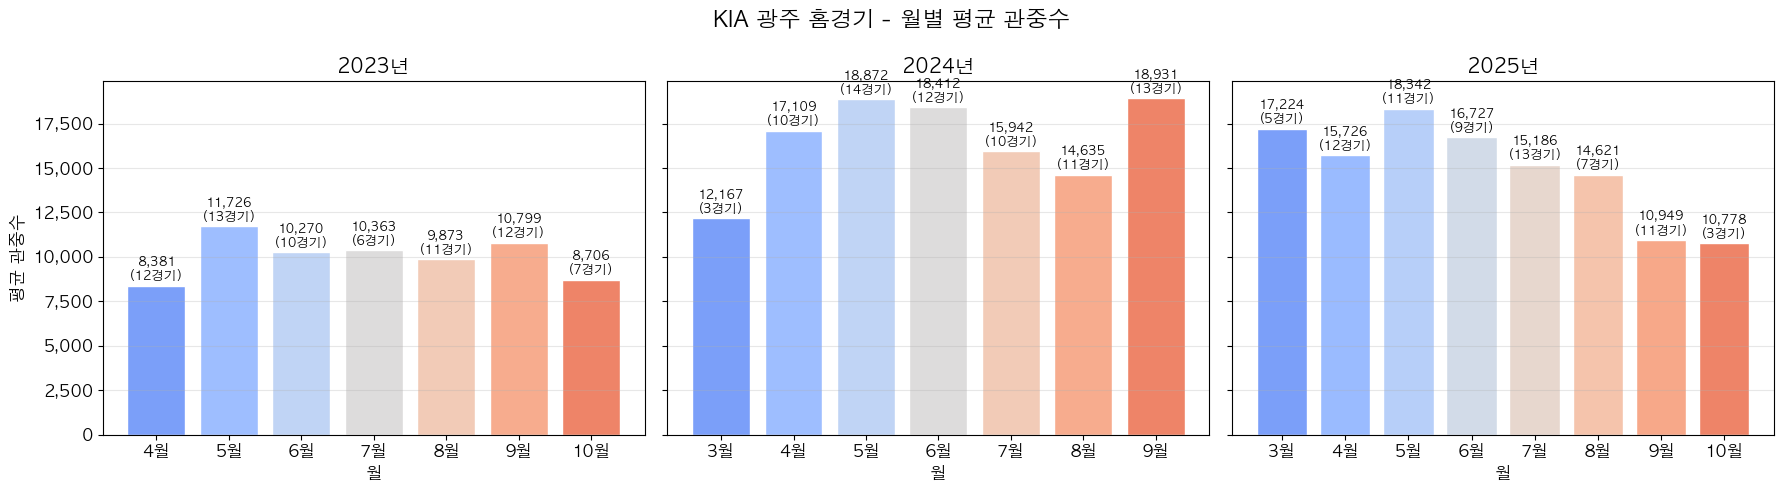

/var/folders/3w/7bj38gqs0t58jb31pzzbbybr0000gn/T/ipykernel_11001/812203997.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_year, labels=[f'{y}년' for y in years], patch_artist=True,


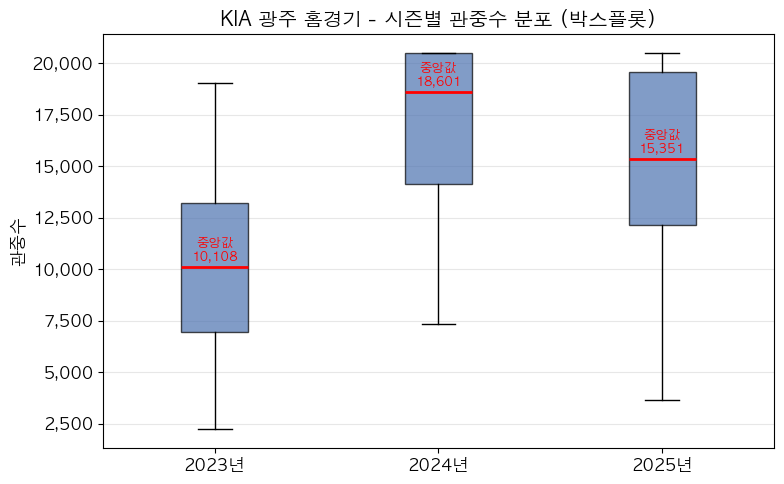

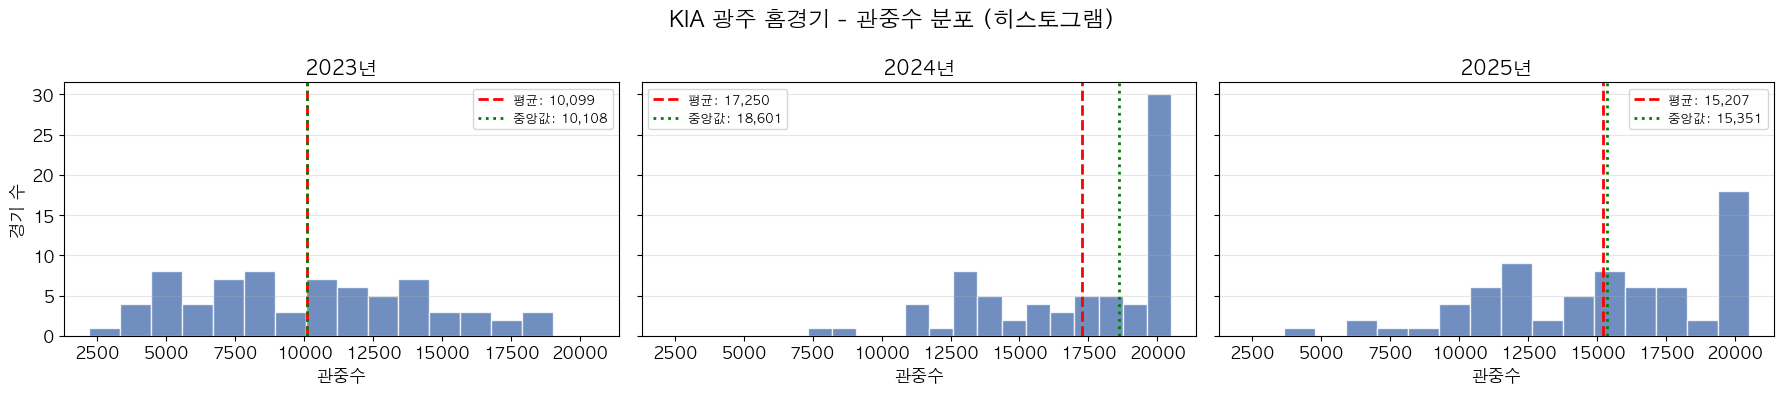

In [72]:
# ========================================
# 1. 월별 관중수 추이
# ========================================
if '월' not in df.columns:
    df['월'] = pd.to_datetime(df['날짜']).dt.month

fig, axes = plt.subplots(1, len(years), figsize=(6 * len(years), 5), sharey=True)
axes = np.atleast_1d(axes)

for ax, year in zip(axes, years):
    year_df = df[df['연도'] == year]
    monthly = year_df.groupby('월')['관중수'].agg(['mean', 'count'])
    
    bars = ax.bar(monthly.index, monthly['mean'], color=plt.cm.coolwarm(np.linspace(0.2, 0.8, len(monthly))),
                  edgecolor='white')
    
    for bar, (m, row) in zip(bars, monthly.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{row["mean"]:,.0f}\n({int(row["count"])}경기)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_title(f'{year}년', fontsize=14, fontweight='bold')
    ax.set_xlabel('월')
    ax.set_xticks(monthly.index)
    ax.set_xticklabels([f'{int(m)}월' for m in monthly.index])
    if ax == axes[0]:
        ax.set_ylabel('평균 관중수')
    ax.grid(axis='y', alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('KIA 광주 홈경기 - 월별 평균 관중수', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ========================================
# 4. 관중수 분포 (박스플롯 + 히스토그램)
# ========================================

# 4-1. 시즌별 박스플롯
fig, ax = plt.subplots(figsize=(8, 5))
data_by_year = [df[df['연도'] == y]['관중수'].values for y in years]
bp = ax.boxplot(data_by_year, labels=[f'{y}년' for y in years], patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))

for i, year in enumerate(years):
    year_data = df[df['연도'] == year]['관중수']
    ax.text(i + 1, year_data.median() + 300, f'중앙값\n{year_data.median():,.0f}',
            ha='center', fontsize=9, fontweight='bold', color='red')

ax.set_title('KIA 광주 홈경기 - 시즌별 관중수 분포 (박스플롯)', fontsize=14, fontweight='bold')
ax.set_ylabel('관중수')
ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

# 4-2. 시즌별 히스토그램
fig, axes = plt.subplots(1, len(years), figsize=(6 * len(years), 4), sharey=True, sharex=True)
axes = np.atleast_1d(axes)

for ax, year in zip(axes, years):
    year_data = df[df['연도'] == year]['관중수']
    ax.hist(year_data, bins=15, color='#4C72B0', edgecolor='white', alpha=0.8)
    ax.axvline(year_data.mean(), color='red', linestyle='--', linewidth=2, label=f'평균: {year_data.mean():,.0f}')
    ax.axvline(year_data.median(), color='green', linestyle=':', linewidth=2, label=f'중앙값: {year_data.median():,.0f}')
    ax.set_title(f'{year}년', fontsize=14, fontweight='bold')
    ax.set_xlabel('관중수')
    if ax == axes[0]:
        ax.set_ylabel('경기 수')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('KIA 광주 홈경기 - 관중수 분포 (히스토그램)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


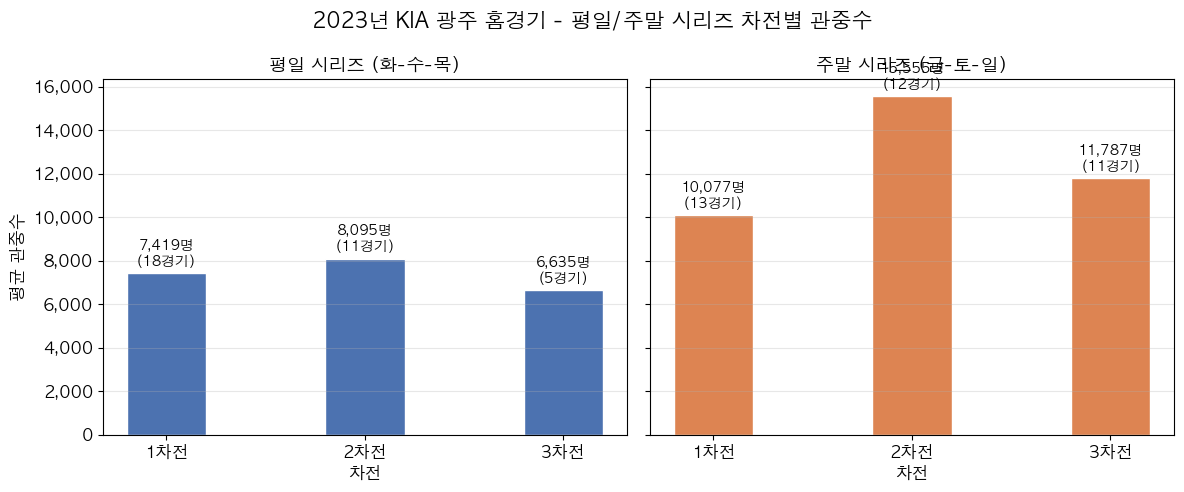

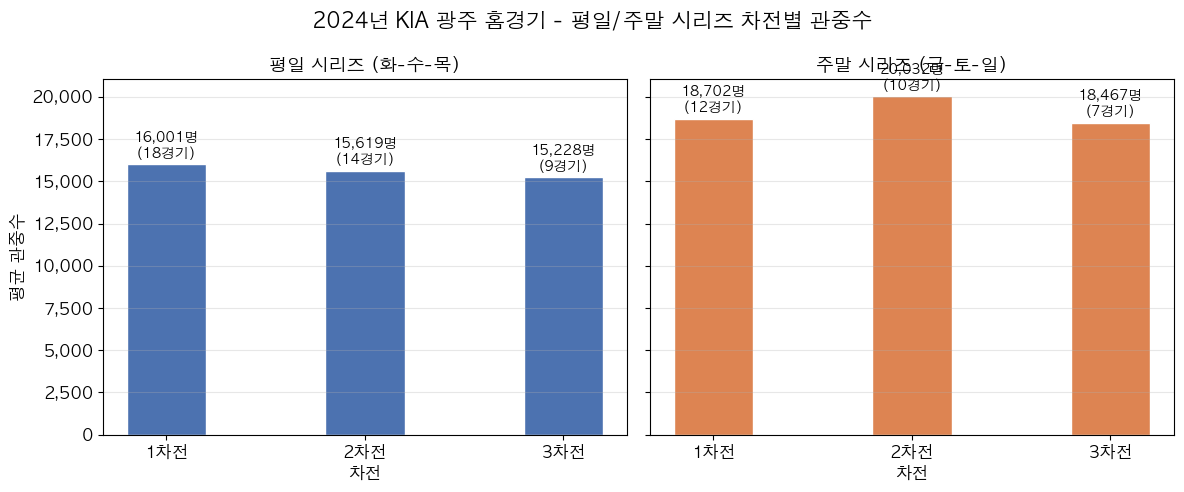

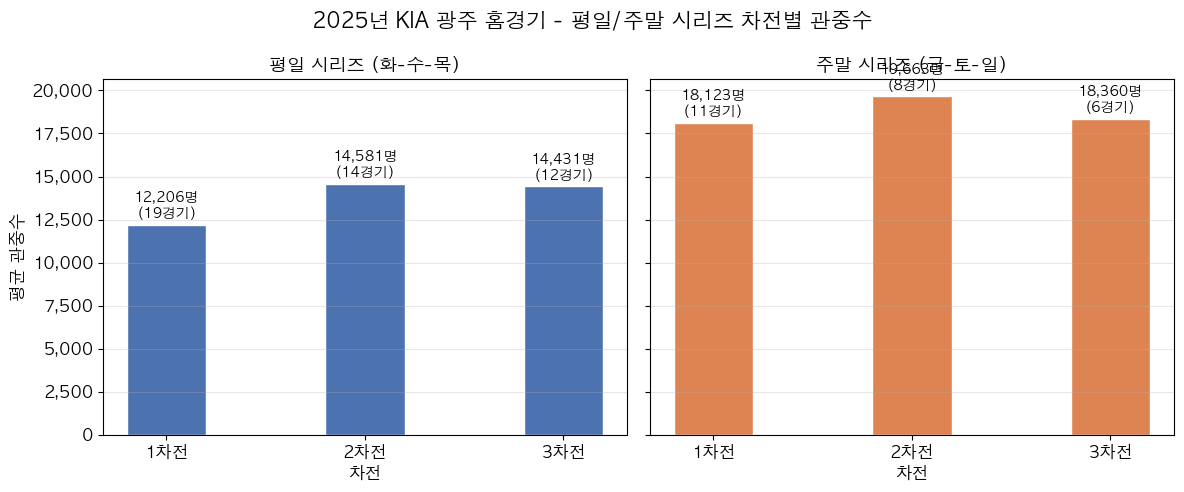

In [73]:
# ========================================
# 평일 시리즈 vs 주말 시리즈 차전별 관중수
# ========================================
df_sorted = df.sort_values('날짜').copy()
df_sorted['상대변경'] = (df_sorted['방문'] != df_sorted['방문'].shift(1)).astype(int)
df_sorted['시리즈ID'] = df_sorted['상대변경'].cumsum()
df_sorted['시리즈_차전'] = df_sorted.groupby('시리즈ID').cumcount() + 1

# 시리즈의 첫 경기 요일로 평일/주말 시리즈 구분
series_start_day = df_sorted.groupby('시리즈ID')['요일'].first()
weekend_series = series_start_day[series_start_day.isin(['금', '토'])].index
weekday_series = series_start_day[~series_start_day.isin(['금', '토', '일'])].index

df_sorted['시리즈구분'] = df_sorted['시리즈ID'].apply(
    lambda x: '주말 시리즈 (금-토-일)' if x in weekend_series else '평일 시리즈 (화-수-목)')

df_series = df_sorted[df_sorted['시리즈_차전'] <= 3]

for year in years:
    year_df = df_series[df_series['연도'] == year]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    
    for ax, stype in zip(axes, ['평일 시리즈 (화-수-목)', '주말 시리즈 (금-토-일)']):
        sub = year_df[year_df['시리즈구분'] == stype]
        avg = sub.groupby('시리즈_차전')['관중수'].agg(['mean', 'count'])
        
        color = '#4C72B0' if '평일' in stype else '#DD8452'
        bars = ax.bar(avg.index, avg['mean'], color=color, edgecolor='white', width=0.4)
        
        for bar, (g, row) in zip(bars, avg.iterrows()):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                    f'{row["mean"]:,.0f}명\n({int(row["count"])}경기)',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        ax.set_title(stype, fontsize=13, fontweight='bold')
        ax.set_xlabel('차전')
        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels(['1차전', '2차전', '3차전'])
        if ax == axes[0]:
            ax.set_ylabel('평균 관중수')
        ax.grid(axis='y', alpha=0.3)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    
    plt.suptitle(f'{year}년 KIA 광주 홈경기 - 평일/주말 시리즈 차전별 관중수', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [74]:
print(f"총 컬럼 수: {len(df.columns)}개\n")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")


총 컬럼 수: 32개

   1. 날짜
   2. 경기_시간
   3. 상태
   4. 홈
   5. 방문
   6. 홈_점수
   7. 방문_점수
   8. 승리팀
   9. 경기_순번
  10. 더블헤더냐
  11. 실제_진행_순번
  12. 요일
  13. 구장
  14. 관중수
  15. 지점명
  16. 지점
  17. 평균기온(°C)
  18. 일강수량(mm)
  19. 평균 풍속(m/s)
  20. 합계 일사량(MJ/m2)
  21. 평균 전운량(1/10)
  22. 연도_x
  23. 평균 상대습도(%)
  24. 홈팀_일간순위
  25. 홈팀_승률
  26. 방문팀_일간순위
  27. 방문팀_승률
  28. 연도_y
  29. 동원율
  30. 연도
  31. 일구분
  32. 월


In [75]:
drop_cols = ['홈_점수', '방문_점수', '승리팀','실제_진행_순번', '연도_x', '연도_y', '상태','지점명','일강수량(mm)', '평균 풍속(m/s)', '합계 일사량(MJ/m2)', '평균 전운량(1/10)']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

print(f"✅ 삭제 완료! 남은 컬럼 수: {len(df.columns)}개")
print(df.columns.tolist())
df.head()

✅ 삭제 완료! 남은 컬럼 수: 20개
['날짜', '경기_시간', '홈', '방문', '경기_순번', '더블헤더냐', '요일', '구장', '관중수', '지점', '평균기온(°C)', '평균 상대습도(%)', '홈팀_일간순위', '홈팀_승률', '방문팀_일간순위', '방문팀_승률', '동원율', '연도', '일구분', '월']


,날짜,경기_시간,홈,방문,경기_순번,더블헤더냐,요일,구장,관중수,지점,평균기온(°C),평균 상대습도(%),홈팀_일간순위,홈팀_승률,방문팀_일간순위,방문팀_승률,동원율,연도,일구분,월
0,2023-04-07,18:30,KIA,두산,1,0,금,광주,12821,156.0,8.8,77.3,5,0.333333,2,0.666667,67.4,2023,평일,4
1,2023-04-08,17:00,KIA,두산,1,0,토,광주,16432,156.0,9.2,47.6,5,0.500000,4,0.571429,86.3,2023,주말/공휴일,4
2,2023-04-09,14:00,KIA,두산,1,0,일,광주,14070,156.0,11.0,47.5,5,0.400000,3,0.625000,73.9,2023,주말/공휴일,4
3,2023-04-11,18:30,KIA,한화,1,0,화,광주,3623,156.0,16.0,77.4,5,0.333333,6,0.250000,19.0,2023,평일,4
4,2023-04-12,18:30,KIA,한화,1,0,수,광주,5252,156.0,13.2,19.4,3,0.428571,5,0.222222,27.6,2023,평일,4


In [76]:
# =============================================
# 5. 피처 엔지니어링 추가 (관중수 Lag 등)
# =============================================

# 5-1. 직전 경기 관중수 (Lag Feature)
df['날짜'] = pd.to_datetime(df['날짜'])
df = df.sort_values('날짜').reset_index(drop=True)
df['관중수_lag1'] = df['관중수'].shift(1).fillna(df['관중수'].median())

print("✅ 5단계 완료: Lag 피처 생성 (관중수_lag1)")

# 5-2. 방문팀 인코딩 (초기화 - 나중에 학습 루프에서 수행)
df['방문팀_코드'] = 0

# =============================================
# 같은 상대와의 시리즈 내 차전 번호
# =============================================
df_sorted = df.sort_values('날짜').copy()
df_sorted['상대변경'] = (df_sorted['방문'] != df_sorted['방문'].shift(1)).astype(int)
df_sorted['시리즈ID'] = df_sorted['상대변경'].cumsum()
df_sorted['시리즈차전'] = df_sorted.groupby('시리즈ID').cumcount() + 1
df['시리즈차전'] = df_sorted['시리즈차전'].values

print("✅ 10단계 완료: 시리즈 내 차전 번호 (시리즈차전)")

✅ 3단계 완료: 요일 관련 인코딩 (요일_숫자, 주말여부, 금요일여부)
✅ 4단계 완료: 일구분 인코딩 (주말공휴일여부)
✅ 5단계 완료: 방문팀 평균 관중수 타겟 인코딩 적용 (총 9개 팀)
✅ 10단계 완료: 시리즈 내 차전 번호 (시리즈차전)

📊 전처리 완료!
  전체 행 수: 215
  전체 컬럼 수: 26
  결측치 수: 0

  사용할 피처 (25개):
     1. 날짜
     2. 경기_시간
     3. 홈
     4. 방문
     5. 경기_순번
     6. 더블헤더냐
     7. 요일
     8. 구장
    10. 지점
    11. 평균기온(°C)
    12. 평균 상대습도(%)
    13. 홈팀_일간순위
    14. 홈팀_승률
    15. 방문팀_일간순위
    16. 방문팀_승률
    17. 동원율
    18. 연도
    19. 일구분
    20. 월
    21. 요일_숫자
    22. 주말여부
    23. 금요일여부
    24. 주말공휴일여부
    25. 방문팀_코드
    26. 시리즈차전

  타겟 변수: 관중수


,날짜,경기_시간,홈,방문,경기_순번,더블헤더냐,요일,구장,관중수,지점,...,동원율,연도,일구분,월,요일_숫자,주말여부,금요일여부,주말공휴일여부,방문팀_코드,시리즈차전
0,2023-04-07,18:30,KIA,두산,1,0,금,광주,12821,156.0,...,67.4,2023,평일,4,4,0,1,0,15910.913043,1
1,2023-04-08,17:00,KIA,두산,1,0,토,광주,16432,156.0,...,86.3,2023,주말/공휴일,4,5,1,0,1,15910.913043,2
2,2023-04-09,14:00,KIA,두산,1,0,일,광주,14070,156.0,...,73.9,2023,주말/공휴일,4,6,1,0,1,15910.913043,3
3,2023-04-11,18:30,KIA,한화,1,0,화,광주,3623,156.0,...,19.0,2023,평일,4,1,0,0,0,14643.880000,1
4,2023-04-12,18:30,KIA,한화,1,0,수,광주,5252,156.0,...,27.6,2023,평일,4,2,0,0,0,14643.880000,2


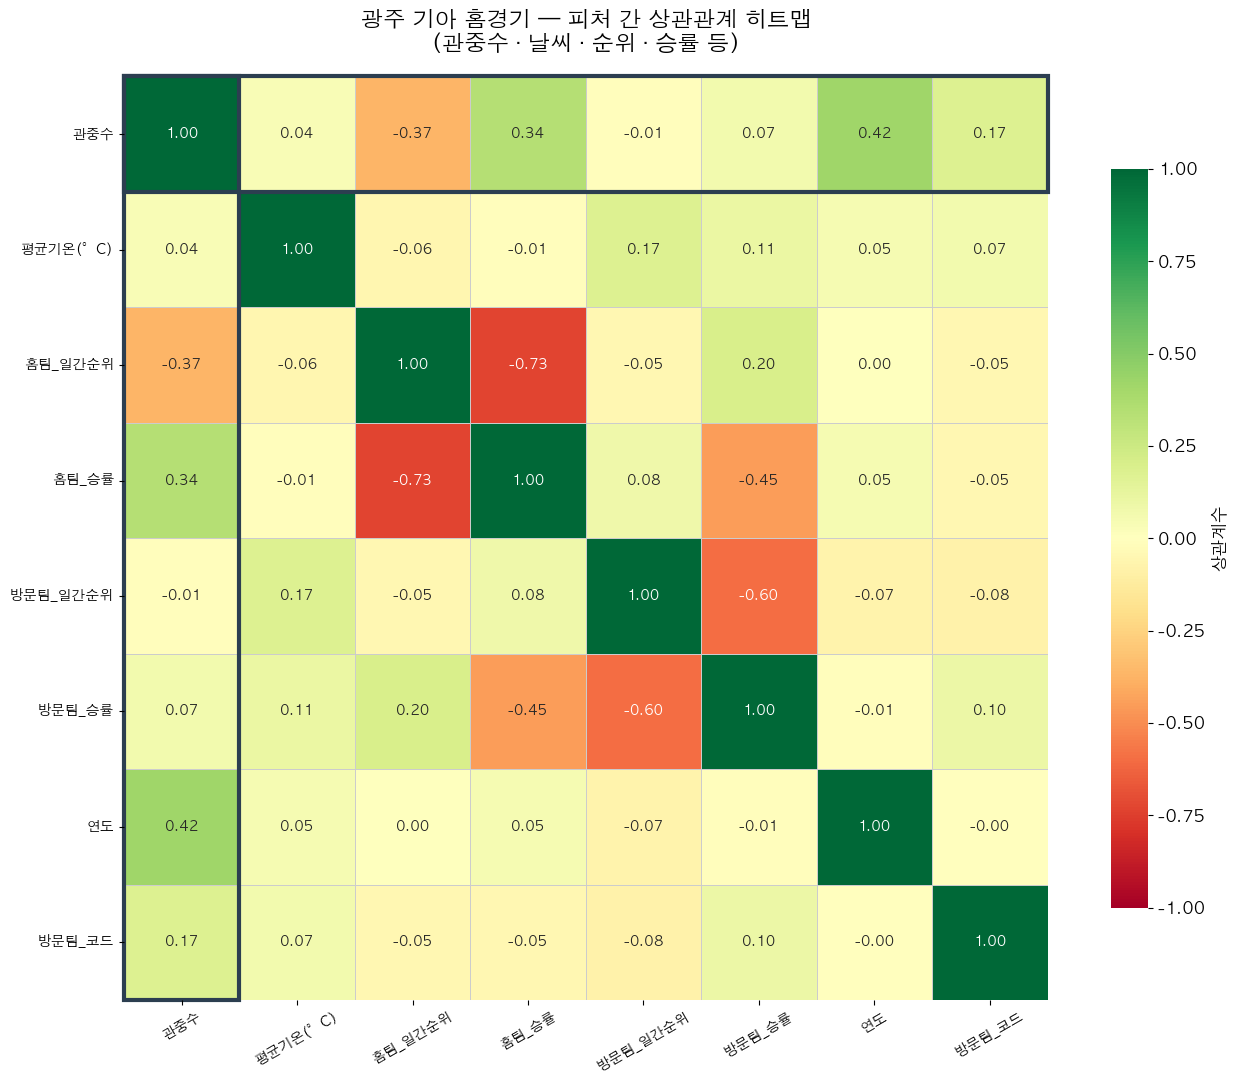

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

# 상관계수 계산 및 시각화
numeric_cols = ['관중수', '홈_점수', '방문_점수', '평균기온(°C)', '일강수량(mm)', '평균 풍속(m/s)', '홈팀_일간순위', '홈팀_승률', '연도']
df_corr = df[[c for c in numeric_cols if c in df.columns]].select_dtypes(include=['number']).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(df_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

In [78]:
import pandas as pd
import numpy as np
import gc

# 데이터 복사
df_model = df.copy()
target = '관중수'
# [Refine] 제거해야 할 데이터 누수 컬럼 (결과 데이터)
leakage_results = ['홈_점수', '방문_점수', '승리팀', '승패', '결과', '동원율', '시즌최대관중']
df_model = df_model.drop(columns=[c for c in leakage_results if c in df_model.columns], errors='ignore')

# [Refine] 상호작용 항 생성 (주말 * 순위)
if '주말여부' in df_model.columns and '홈팀_일간순위' in df_model.columns:
    df_model['주말_순위_상호작용'] = df_model['주말여부'] * (11 - df_model['홈팀_일간순위'])

# [Refine] 래그 피처 추가 (직전 경기 관중수)
if '날짜' in df_model.columns:
    df_model = df_model.sort_values('날짜')
    df_model['관중수_lag1'] = df_model['관중수'].shift(1).fillna(df_model['관중수'].mean())


# 중복 및 불필요 컬럼 제거
leak_cols = ['동원율', '시즌최대관중']
df_model = df_model.drop(columns=[c for c in leak_cols if c in df_model.columns])
df_model = df_model.loc[:, ~df_model.columns.duplicated()].copy()

if '날짜' in df_model.columns:
    df_model['날짜'] = pd.to_datetime(df_model['날짜'])
    df_model = df_model.sort_values('날짜')

year_col = '연도' if '연도' in df_model.columns else '년도'
years = sorted(df_model[year_col].dropna().unique())

# 결과를 담을 빈 바구니 (딕셔너리)
all_preds = {year: {} for year in years}

print("✅ 1단계 완료")

✅ 1단계 완료


In [79]:
import xgboost as xgb
print('▶ 1번 주자 XGBoost 출발! (데이터 누수 방지 및 가중치 최적화)')

for year in years:
    train_cond = (df_model[year_col] < year) | ((df_model[year_col] == year) & (df_model['월'] <= 8))
    test_cond = (df_model[year_col] == year) & (df_model['월'] >= 9)
    if len(df_model[test_cond]) == 0: continue
    
    # 1. 학습 데이터 기준으로 방문팀 타겟 인코딩 (누수 방지)
    train_df = df_model[train_cond].copy()
    test_df = df_model[test_cond].copy()
    
    visitor_mean = train_df.groupby('방문')[target].mean()
    train_df['방문팀_코드'] = train_df['방문'].map(visitor_mean)
    test_df['방문팀_코드'] = test_df['방문'].map(visitor_mean).fillna(train_df[target].mean())
    
    # 수치형 데이터 선택
    X_train = train_df.select_dtypes(include=[np.number]).drop(columns=[target], errors='ignore')
    y_train = train_df[target]
    X_test = test_df.select_dtypes(include=[np.number]).drop(columns=[target], errors='ignore')
    
    # 2. 가중치 설정 (안정성 강화)
    sw = np.ones(len(y_train))
    if year == 2024:
        # 과도한 50.0 가중치를 5.0으로 하향 조정하여 일반화 능력 향상
        sw[X_train.get('홈팀_일간순위', 0) == 1] = 3.0
        sw[(X_train.get('홈팀_일간순위', 0) == 1) & (X_train['월'] == 8)] = 5.0
    elif year == 2025:
        sw[X_train.get('홈팀_일간순위', 0) == 1] = 3.0
        sw[X_train['주말공휴일여부'] == 1] = 2.0
        
    model = xgb.XGBRegressor(
        n_estimators=200, 
        learning_rate=0.05, 
        max_depth=5, 
        n_jobs=1,
        tree_method='hist',
        verbosity=0,
        random_state=42
    )
    model.fit(X_train, y_train, sample_weight=sw)
    all_preds[year]['XGB'] = np.clip(model.predict(X_test), 0, MAX_CAPACITY)
    print(f'  - {year}년 XGB 완료')
    
    del model, X_train, y_train, X_test; gc.collect()

▶ 1번 주자 XGBoost 출발!


  - 2023년 XGB 완료
  - 2024년 XGB 완료
  - 2025년 XGB 완료


78422

In [80]:
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.linear_model import LinearRegression; import lightgbm as lgb; from catboost import CatBoostRegressor
print('▶ 2번 주자들(LGB, Cat, LR) - 데이터 누수 방지 및 가중치 최적화')

for year in years:
    train_cond = (df_model[year_col] < year) | ((df_model[year_col] == year) & (df_model['월'] <= 8))
    test_cond = (df_model[year_col] == year) & (df_model['월'] >= 9)
    if len(df_model[test_cond]) == 0: continue
    
    train_df = df_model[train_cond].copy()
    test_df = df_model[test_cond].copy()
    visitor_mean = train_df.groupby('방문')[target].mean()
    train_df['방문팀_코드'] = train_df['방문'].map(visitor_mean)
    test_df['방문팀_코드'] = test_df['방문'].map(visitor_mean).fillna(train_df[target].mean())
    
    X_train = train_df.select_dtypes(include=[np.number]).drop(columns=[target], errors='ignore').fillna(0)
    y_train = train_df[target].fillna(0)
    X_test = test_df.select_dtypes(include=[np.number]).drop(columns=[target], errors='ignore').fillna(0)
    
    sw = np.ones(len(y_train))
    if year == 2024:
        sw[X_train.get('홈팀_일간순위', 0) == 1] = 3.0
        sw[(X_train.get('홈팀_일간순위', 0) == 1) & (X_train['월'] == 8)] = 5.0
    elif year == 2025:
        sw[X_train.get('홈팀_일간순위', 0) == 1] = 3.0
        sw[X_train['주말공휴일여부'] == 1] = 2.0
        
    m_lgb = lgb.LGBMRegressor(n_estimators=300, n_jobs=1, verbose=-1).fit(X_train, y_train, sample_weight=sw)
    all_preds[year]['LGB'] = np.clip(m_lgb.predict(X_test), 0, MAX_CAPACITY)
    m_cat = CatBoostRegressor(iterations=300, thread_count=1, verbose=0).fit(X_train, y_train, sample_weight=sw)
    all_preds[year]['Cat'] = np.clip(m_cat.predict(X_test), 0, MAX_CAPACITY)
    m_lr = LinearRegression().fit(X_train, y_train, sample_weight=sw)
    all_preds[year]['LR'] = np.clip(m_lr.predict(X_test), 0, MAX_CAPACITY)
    del m_lgb, m_cat, m_lr, X_train, y_train, X_test; gc.collect()

▶ 2번 주자들(LGB, Cat, LR)


In [81]:
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR

print('▶ MLP & GKFN 시작! - 데이터 누수 방지 및 스케일링 최적화')
for year in years:
    train_cond = (df_model[year_col] < year) | ((df_model[year_col] == year) & (df_model['월'] <= 8))
    test_cond = (df_model[year_col] == year) & (df_model['월'] >= 9)
    if len(df_model[test_cond]) == 0: continue
    
    train_df = df_model[train_cond].copy()
    test_df = df_model[test_cond].copy()
    visitor_mean = train_df.groupby('방문')[target].mean()
    train_df['방문팀_코드'] = train_df['방문'].map(visitor_mean)
    test_df['방문팀_코드'] = test_df['방문'].map(visitor_mean).fillna(train_df[target].mean())
    
    X_train = train_df.select_dtypes(include=['number']).drop(columns=[target], errors='ignore').fillna(0)
    y_train = train_df[target].fillna(0)
    X_test = test_df.select_dtypes(include=['number']).drop(columns=[target], errors='ignore').fillna(0)
    
    xs, ys = StandardScaler(), StandardScaler()
    xt_s, xtest_s = xs.fit_transform(X_train), xs.transform(X_test)
    yt_s = ys.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    
    all_preds[year]['MLP'] = np.clip(ys.inverse_transform(MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42).fit(xt_s, yt_s).predict(xtest_s).reshape(-1, 1)).flatten(), 0, MAX_CAPACITY)
    all_preds[year]['GKFN'] = np.clip(ys.inverse_transform(SVR(kernel='rbf', C=10).fit(xt_s, yt_s).predict(xtest_s).reshape(-1, 1)).flatten(), 0, MAX_CAPACITY)
    del xt_s, xtest_s, yt_s; gc.collect()

▶ MLP & GKFN 시작!


In [ ]:
from pytorch_tabnet.tab_model import TabNetRegressor

# [Refine] ▶ 4번 주자 TabNet 시작! (정형 데이터 최적화 딥러닝)
print('▶ 4번 주자 TabNet 시작! - 데이터 누수 방지 및 어텐션 기반 학습')

for year in years:
    train_cond = (df_model[year_col] < year) | ((df_model[year_col] == year) & (df_model['월'] <= 8))
    test_cond = (df_model[year_col] == year) & (df_model['월'] >= 9)
    if len(df_model[test_cond]) == 0: continue
    
    train_df = df_model[train_cond].copy()
    test_df = df_model[test_cond].copy()
    
    # 방문팀 타겟 인코딩 (누수 방지)
    visitor_mean = train_df.groupby('방문')[target].mean()
    train_df['방문팀_코드'] = train_df['방문'].map(visitor_mean)
    test_df['방문팀_코드'] = test_df['방문'].map(visitor_mean).fillna(train_df[target].mean())
    
    X_train = train_df.select_dtypes(include=[np.number]).drop(columns=[target], errors='ignore').fillna(0).values.astype('float32')
    y_train = train_df[target].fillna(0).values.reshape(-1, 1).astype('float32')
    X_test = test_df.select_dtypes(include=[np.number]).drop(columns=[target], errors='ignore').fillna(0).values.astype('float32')
    
    # 스케일링
    from sklearn.preprocessing import StandardScaler
    xs, ys = StandardScaler(), StandardScaler()
    xt_s = xs.fit_transform(X_train)
    yt_s = ys.fit_transform(y_train).flatten()
    xtest_s = xs.transform(X_test)
    
    # TabNet 모델 설정 및 학습
    # 하이퍼파라미터는 KBO 데이터셋 규모에 맞춰 조정됨
    reg_tab = TabNetRegressor(
        n_d=16, n_a=16, n_steps=3,
        gamma=1.3, lambda_sparse=1e-3,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-2),
        scheduler_params={"step_size":50, "gamma":0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type='entmax',
        verbose=0
    )
    
    reg_tab.fit(
        X_train=xt_s, y_train=yt_s.reshape(-1, 1),
        max_epochs=100, patience=20,
        batch_size=128, virtual_batch_size=64,
        num_workers=0, drop_last=False
    )
    
    # 예측 및 클리핑
    pred_s = reg_tab.predict(xtest_s)
    all_preds[year]['TabNet'] = np.clip(ys.inverse_transform(pred_s).flatten(), 0, MAX_CAPACITY)
    
    print(f'  - {year}년 TabNet 완료')
    import gc; del reg_tab, xt_s, yt_s, xtest_s; gc.collect()


ARIMA 단독! 연도별 가을야구 예측 시작!

⏳ 2023년 ARIMA가 관중수를 계산하고 있습니다...
✅ 2023년 채점 -> ARIMA 오차: 3,544명
⏳ 2024년 ARIMA가 관중수를 계산하고 있습니다...
✅ 2024년 채점 -> ARIMA 오차: 5,709명
⏳ 2025년 ARIMA가 관중수를 계산하고 있습니다...
✅ 2025년 채점 -> ARIMA 오차: 4,652명


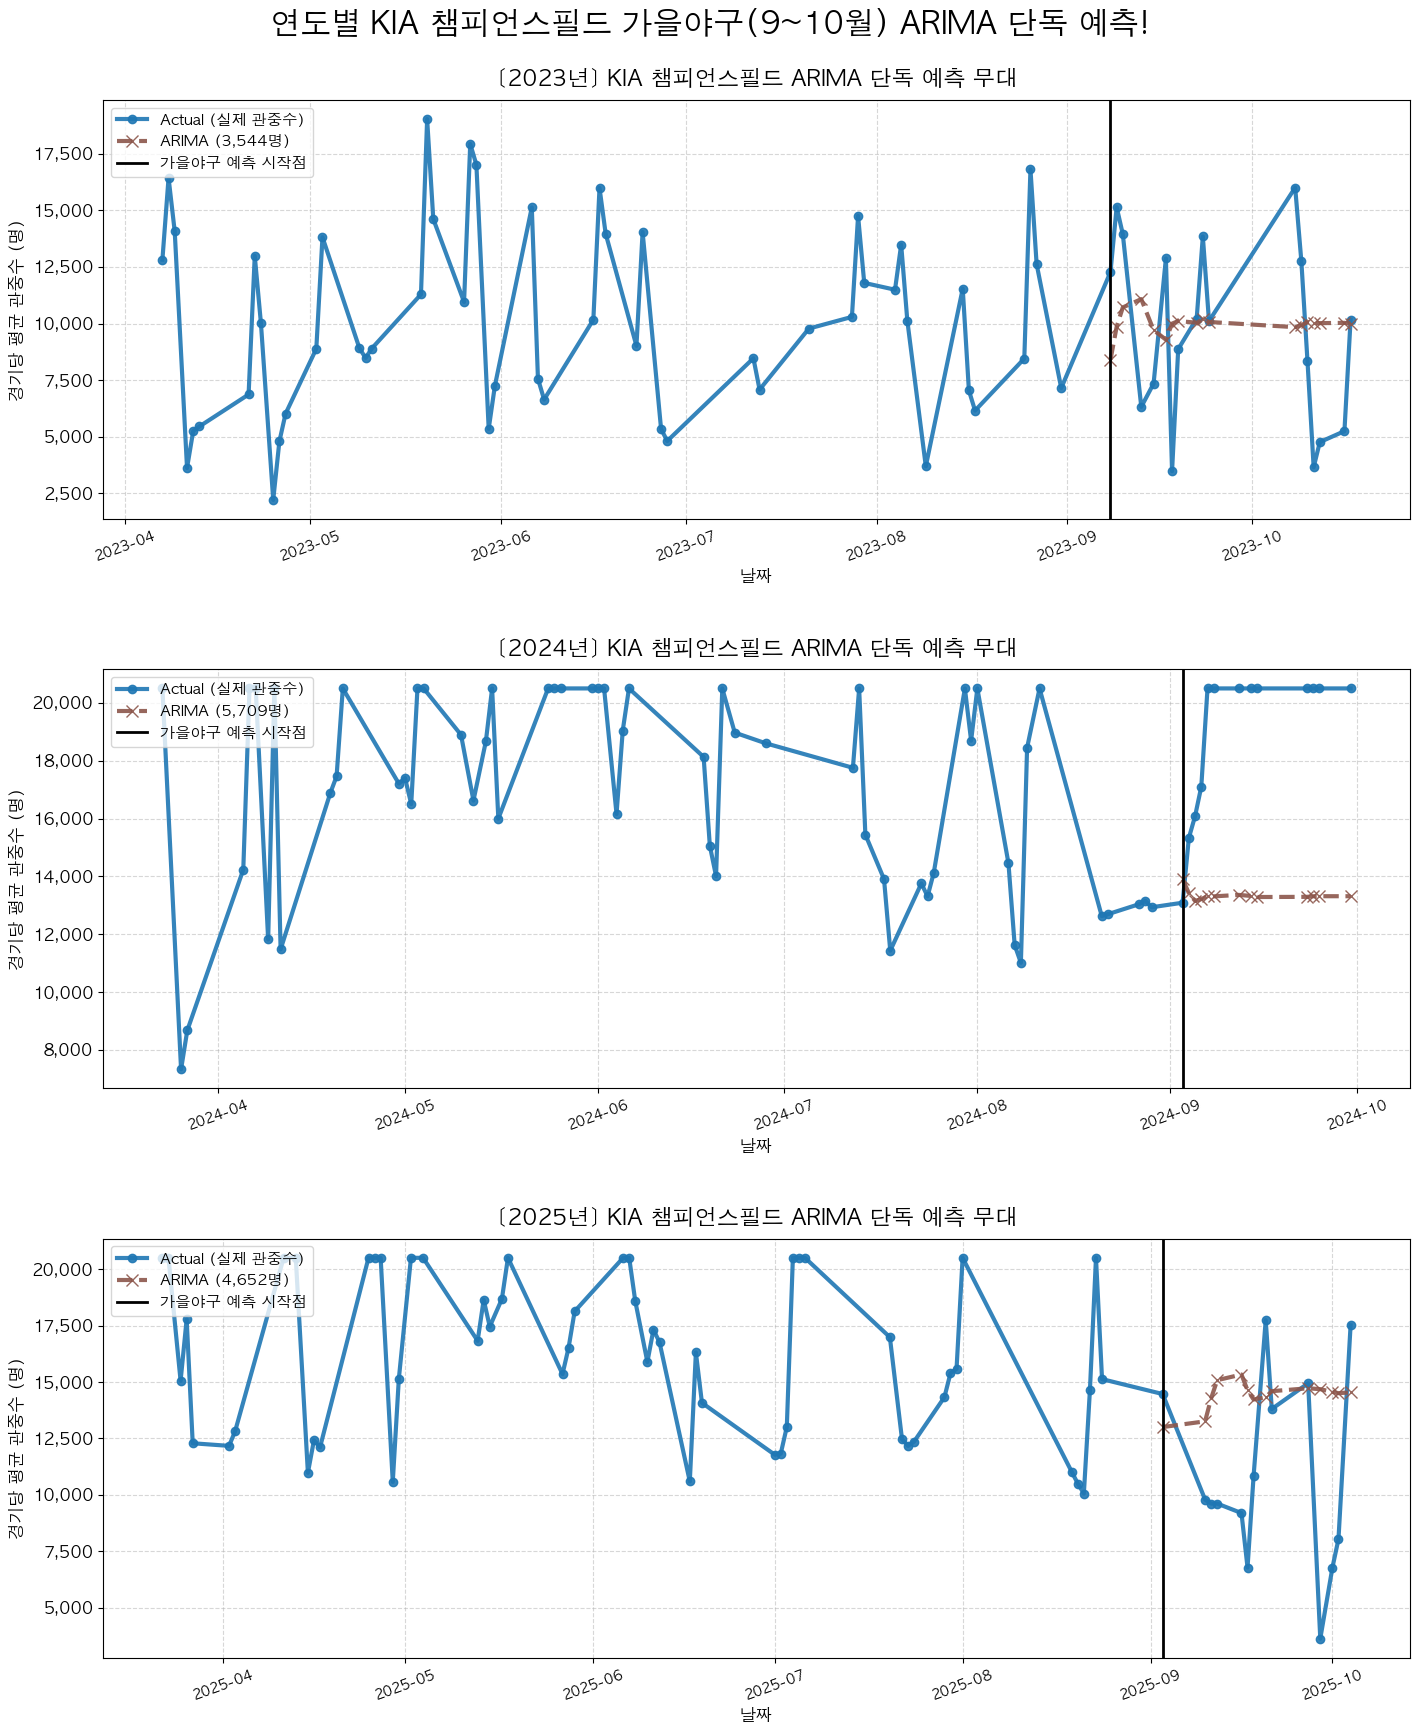

----------------------------------------------------------------------------------------------------


In [82]:
from pytorch_tabnet.tab_model import TabNetRegressor
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
os.environ['OMP_NUM_THREADS'] = '1' 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from sklearn.metrics import mean_absolute_error
import statsmodels.api as sm

print("ARIMA 단독! 연도별 가을야구 예측 시작!\n")

# 밀크쨩이 완성해둔 데이터(df)를 모델용으로 안전하게 복사
df_model = df.copy()
target = '관중수'
# [Refine] 제거해야 할 데이터 누수 컬럼 (결과 데이터)
leakage_results = ['홈_점수', '방문_점수', '승리팀', '승패', '결과', '동원율', '시즌최대관중']
df_model = df_model.drop(columns=[c for c in leakage_results if c in df_model.columns], errors='ignore')

# [Refine] 상호작용 항 생성 (주말 * 순위)
if '주말여부' in df_model.columns and '홈팀_일간순위' in df_model.columns:
    df_model['주말_순위_상호작용'] = df_model['주말여부'] * (11 - df_model['홈팀_일간순위'])

# [Refine] 래그 피처 추가 (직전 경기 관중수)
if '날짜' in df_model.columns:
    df_model = df_model.sort_values('날짜')
    df_model['관중수_lag1'] = df_model['관중수'].shift(1).fillna(df_model['관중수'].mean())


# 누수 변수 및 중복 컬럼 완벽 차단!
leak_cols = ['동원율', '시즌최대관중']
df_model = df_model.drop(columns=[c for c in leak_cols if c in df_model.columns])
if df_model.columns.duplicated().any():
    df_model = df_model.loc[:, ~df_model.columns.duplicated()].copy()

# 날짜 데이터 처리
if '날짜' in df_model.columns:
    df_model['날짜'] = pd.to_datetime(df_model['날짜'])
    df_model = df_model.sort_values('날짜')

# 연도 파악
year_col = '연도' if '연도' in df_model.columns else '년도'
years = sorted(df_model[year_col].dropna().unique())

# 맥 폰트 세팅
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False 

fig, axes = plt.subplots(nrows=len(years), ncols=1, figsize=(15, 6 * len(years)))
axes = np.atleast_1d(axes)

fig.suptitle('연도별 KIA 챔피언스필드 가을야구(9~10월) ARIMA 단독 예측!', fontsize=22, fontweight='bold', y=0.98)

for i, year in enumerate(years):
    ax = axes[i]
    year_data = df_model[df_model[year_col] == year].copy()
    if len(year_data) == 0: continue
    # 🌟 무대 분할: 3~8월은 과거의 흐름 파악(Train), 9~10월은 미래 예측(Test)
    train_cond = (df_model[year_col] < year) | ((df_model[year_col] == year) & (df_model['월'] <= 8))
    test_cond = (df_model[year_col] == year) & (df_model['월'] >= 9)
    train_data = df_model[train_cond].copy()
    test_data = df_model[test_cond].copy()
    if len(test_data) == 0:
        ax.set_title(f'[{year}년 시즌] 9~10월 테스트 데이터 없음', fontsize=15, color='gray')
        ax.axis('off')
        continue

    # 학습용 데이터 분리 (ARIMA는 X 힌트 없이 정답 y의 과거 패턴만 봅니다)
    y_train = train_data[target]
    y_test = test_data[target]
    # 🔥 클래식 댄서 ARIMA 시작 🔥
    print(f"⏳ {year}년 ARIMA가 관중수를 계산하고 있습니다...")
    try:
        # 과거 데이터 흐름을 분석해서 남은 9~10월 경기 수(len)만큼 미래 궤적 예측!
        # (order=(5,1,0)은 '과거 5경기를 보고, 1번 추세를 보정한다'는 뜻이에요)
        arima_model = sm.tsa.ARIMA(y_train.values, order=(5, 1, 0))
        arima_fit = arima_model.fit()
        pred_arima = arima_fit.forecast(steps=len(y_test))
    except:
        pred_arima = np.zeros(len(y_test))

    # 🌟 채점 (MAE)
    mae_arima = mean_absolute_error(y_test, pred_arima)
    print(f"✅ {year}년 채점 -> ARIMA 오차: {mae_arima:,.0f}명")
    # 🌟 시각화 데이터 준비 (단일 구장 더블헤더 방지용 mean 처리)
    plot_train = train_data[train_data[year_col] == year].copy()
    train_plot_df = pd.DataFrame({'Date': plot_train['날짜'], 'Month': plot_train['월'], 'Actual': plot_train[target].values})
    test_plot_df = pd.DataFrame({
        'Date': test_data['날짜'], 'Month': test_data['월'], 'Actual': y_test.values, 
        'Pred_ARIMA': pred_arima
    })
    full_plot_df = pd.concat([train_plot_df, test_plot_df[['Date', 'Month', 'Actual']]])
    full_plot_grouped = full_plot_df.groupby(['Date', 'Month']).mean().reset_index()
    test_grouped = test_plot_df.groupby(['Date']).mean().reset_index()
    # 🌟 그래프 그리기!
    # 실제 관중수 (파란 선)
    ax.plot(full_plot_grouped['Date'], full_plot_grouped['Actual'], 
            label='Actual (실제 관중수)', color='#1f77b4', marker='o', linewidth=3, markersize=6, alpha=0.9)
    # ARIMA 예측 선 (클래식한 브라운 컬러!)
    ax.plot(test_grouped['Date'], test_grouped['Pred_ARIMA'], label=f'ARIMA ({mae_arima:,.0f}명)', 
            color='#8c564b', marker='x', linestyle='--', linewidth=3, markersize=8, alpha=0.9) 
    # 9월 시작 기준선
    september_first_game = test_plot_df['Date'].min()
    ax.axvline(x=september_first_game, color='black', linestyle='-', linewidth=2, label='가을야구 예측 시작점')
    # 서브플롯 꾸미기
    ax.set_title(f'[{year}년] KIA 챔피언스필드 ARIMA 단독 예측 무대', fontsize=16, fontweight='bold', pad=10)
    ax.set_xlabel('날짜', fontsize=12)
    ax.set_ylabel('경기당 평균 관중수 (명)', fontsize=12) 
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=11, loc='upper left') 
    ax.tick_params(axis='x', rotation=20, labelsize=10)
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.tight_layout(pad=3.0)
fig.subplots_adjust(top=0.93) 
plt.show()
print("-" * 100)

## 🔥 하이브리드 가중치 앙상블 (Ensemble)

In [83]:
print("🚀 모든 모델의 힘을 하나로! 가중치 앙상블 계산 중...")

for year in years:
    preds = all_preds[year]
    
    # 🌟 모델별 가중치 설정 (성능 및 특성 고려)
    # XGB, LGB, Cat: 20%씩 / MLP, GKFN: 15%씩 / ARIMA, LR: 5%씩
    weights = {
            'XGB': 0.20,
            'LGB': 0.20,
            'Cat': 0.20,
            'TabNet': 0.15,
            'MLP': 0.10,
            'GKFN': 0.10,
            'ARIMA': 0.03,
            'LR': 0.02
    }
    
    # 실제 사용 가능한 모델만 필터링 및 가중치 정규화
    available_models = [m for m in weights if m in preds]
    weights = {
            'XGB': 0.20,
            'LGB': 0.20,
            'Cat': 0.20,
            'TabNet': 0.15,
            'MLP': 0.10,
            'GKFN': 0.10,
            'ARIMA': 0.03,
            'LR': 0.02
    }
    total_w = sum(weights.values())
    
    if total_w > 0:
        # 가중 평균 계산
        # 첫 번째 모델 결과로 크기 맞춤
        first_model = available_models[0]
        ensemble_pred = np.zeros_like(preds[first_model])
        
        for m in available_models:
            ensemble_pred += preds[m] * (weights[m] / total_w)
        
        # 최종 수용 인원 제한 적용
        all_preds[year]['Ensemble'] = np.clip(ensemble_pred, 0, MAX_CAPACITY)
    
print("✅ 앙상블 레이더 가동 완료! (Ensemble 컬럼 생성됨)")


🚀 모든 모델의 힘을 하나로! 가중치 앙상블 계산 중...
✅ 앙상블 레이더 가동 완료! (Ensemble 컬럼 생성됨)


📊 기아 챔피언스필드 연도별 추세 및 모델 성능 분석 시작!


/var/folders/3w/7bj38gqs0t58jb31pzzbbybr0000gn/T/ipykernel_11001/3566690504.py:97: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) AppleGothic.
  plt.tight_layout()
/var/folders/3w/7bj38gqs0t58jb31pzzbbybr0000gn/T/ipykernel_11001/3566690504.py:97: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) AppleGothic.
  plt.tight_layout()
/opt/anaconda3/envs/DL/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/DL/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


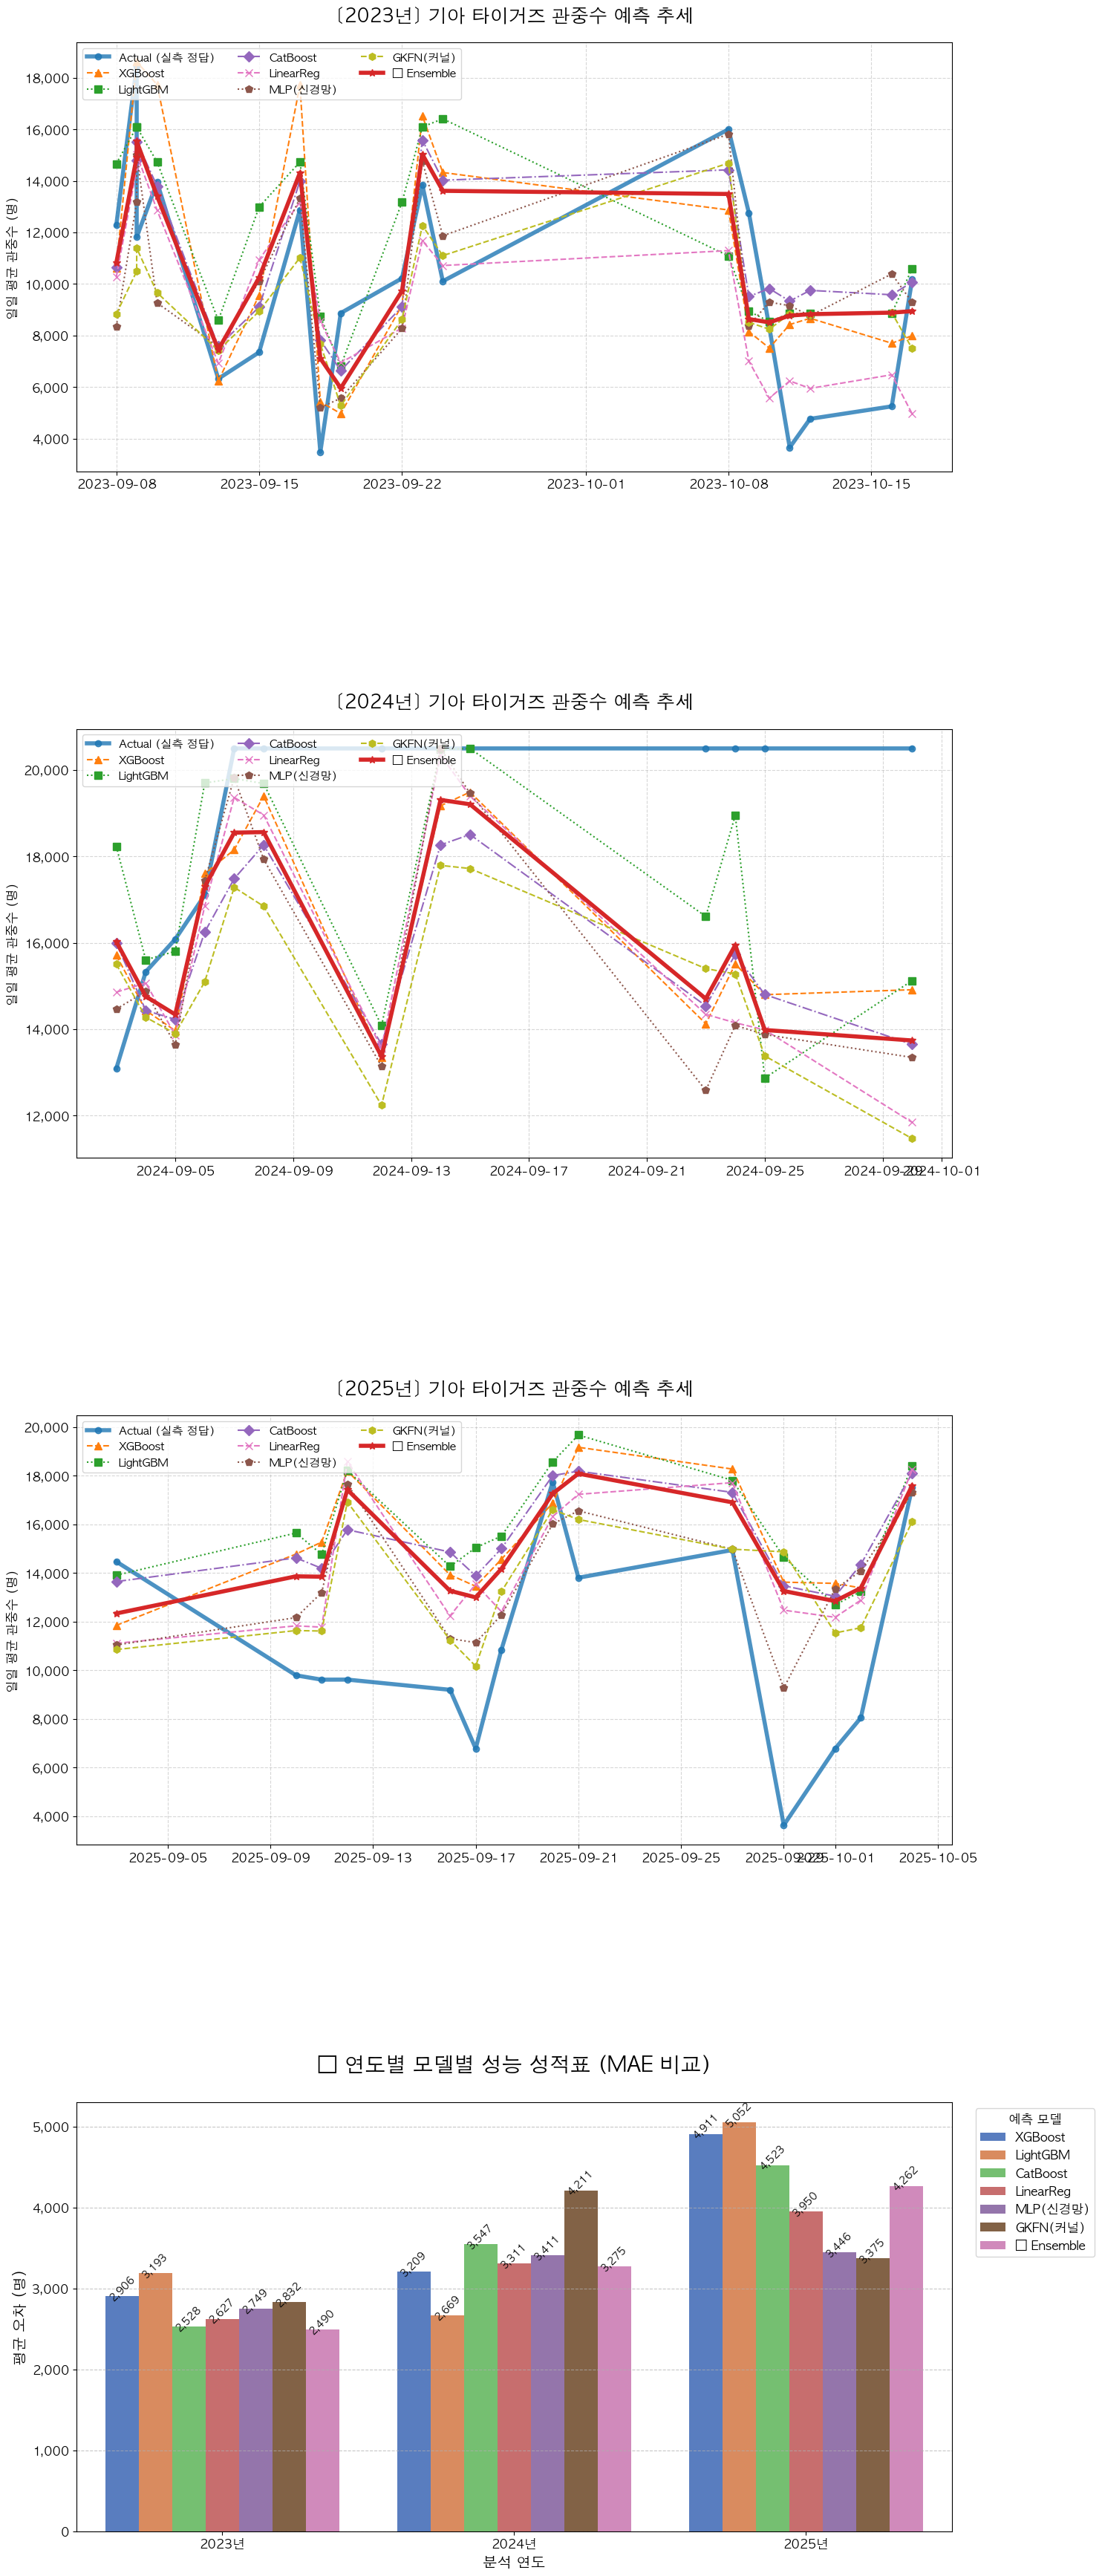

✨ 기아 7대장 메가 크루의 무대가 끝났습니다! 연도별 막대그래프로 누가 1등인지 확인해 봐요! 🥰🛋️✨


In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

# 1. MAPE 계산 함수 정의
def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False 

# 연도별 추세 그래프 개수 + 마지막 성능 비교 그래프 1개 (총 4개 행 예상)
total_rows = len(years) + 1
fig, axes = plt.subplots(nrows=total_rows, ncols=1, figsize=(15, 9 * total_rows))
axes = np.atleast_1d(axes)

# 연도별 성능 데이터를 모으기 위한 리스트
performance_log = []

print("📊 기아 챔피언스필드 연도별 추세 및 모델 성능 분석 시작!")

for i, year in enumerate(years):
    ax = axes[i]
    # 해당 연도 9~10월 테스트 데이터 추출
    test_data = df_model[(df_model[year_col] == year) & (df_model['월'] >= 9)]
    if len(test_data) == 0: continue
    
    y_true = test_data[target].values
    
    # 실제값 (파란색 기준선)
    ax.plot(test_data['날짜'], y_true, label='Actual (실측 정답)', color='#1f77b4', marker='o', linewidth=4, alpha=0.8)
    
    # 7개 모델별 스타일 설정 (XGB까지 포함한 완전체!)
    model_styles = {
        'XGB': {'label': 'XGBoost', 'color': '#ff7f0e', 'ls': '--', 'm': '^'},
        'LGB': {'label': 'LightGBM', 'color': '#2ca02c', 'ls': ':', 'm': 's'},
        'Cat': {'label': 'CatBoost', 'color': '#9467bd', 'ls': '-.', 'm': 'D'},
        'LR':  {'label': 'LinearReg', 'color': '#e377c2', 'ls': '--', 'm': 'x'},
        'ARIMA': {'label': 'ARIMA', 'color': '#17becf', 'ls': '-', 'm': 'v'},
        'MLP': {'label': 'MLP(신경망)', 'color': '#8c564b', 'ls': ':', 'm': 'p'},
        'GKFN': {'label': 'GKFN(커널)', 'color': '#bcbd22', 'ls': '--', 'm': 'h'},
        'Ensemble': {'label': '🔥 Ensemble', 'color': '#d62728', 'ls': '-', 'm': '*', 'lw': 4}
    }

    for m_name, style in model_styles.items():
        if m_name in all_preds[year]:
            y_pred = all_preds[year][m_name]
            
            # MAE와 MAPE 계산
            mae = mean_absolute_error(y_true, y_pred)
            mape = mean_absolute_percentage_error(y_true, y_pred)
            
            # 🌟 성능 데이터를 리스트에 차곡차곡 저장
            performance_log.append({
                '연도': f'{year}년',
                '모델': style['label'],
                'MAE(오차)': mae,
                'MAPE(%)': mape
            })
            
            # 추세 그래프 선 그리기
            lw = style.get('lw', 1.5)
            ax.plot(test_data['날짜'], y_pred, label=style['label'], 
                    linestyle=style['ls'], color=style['color'], marker=style['m'], markersize=7, linewidth=lw)

    ax.set_title(f'[{year}년] 기아 타이거즈 관중수 예측 추세', fontsize=18, fontweight='bold', pad=20)
    ax.legend(loc='upper left', fontsize=11, ncol=3)
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel('일일 평균 관중수 (명)', fontsize=12)

# --- 🌟 마지막 슬라이드: 연도별 성능 비교 막대그래프 (Grouped Bar Chart) ---
ax_perf = axes[-1]
perf_df = pd.DataFrame(performance_log)

# x축: 연도, y축: MAE, 모델별로 색상 구분
sns.barplot(data=perf_df, x='연도', y='MAE(오차)', hue='모델', ax=ax_perf, palette='muted')

# 막대 위에 MAE 수치 표시 (가독성 UP!)
for p in ax_perf.patches:
    if p.get_height() > 0:
        ax_perf.annotate(f'{p.get_height():,.0f}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', fontsize=10, fontweight='bold', 
                         xytext=(0, 8), textcoords='offset points', rotation=45)

ax_perf.set_title('🏆 연도별 모델별 성능 성적표 (MAE 비교)', fontsize=20, fontweight='bold', pad=30)
ax_perf.set_ylabel('평균 오차 (명)', fontsize=14)
ax_perf.set_xlabel('분석 연도', fontsize=14)
ax_perf.legend(title='예측 모델', bbox_to_anchor=(1.02, 1), loc='upper left')
ax_perf.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax_perf.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
# 전체적인 여백 조절
plt.subplots_adjust(top=0.95, hspace=0.6) 
plt.show()

print("✨ 기아 7대장 메가 크루의 무대가 끝났습니다! 연도별 막대그래프로 누가 1등인지 확인해 봐요! 🥰🛋️✨")

In [ ]:

# [Refine] 모델별 최종 성능 요약 테이블 출력
import pandas as pd
if 'performance_log' in locals() or 'performance_data' in locals():
    perf_data = performance_log if 'performance_log' in locals() else performance_data
    summary_df = pd.DataFrame(perf_data)
    
    print("\n" + "="*50)
    print("🏆 최종 모델 성능 요약 성적표 (MAE 기준 정렬)")
    print("="*50)
    
    # 연도별/모델별 평균 MAE 계산
    final_summary = summary_df.groupby('모델')['MAE(오차)'].mean().sort_values().reset_index()
    print(final_summary.to_string(index=False))
    print("="*50)
else:
    print("성능 로그 데이터를 찾을 수 없습니다.")
